# 05 — Entraînement et évaluation des modèles de classification des émissions de CO₂

## Objectif

Ce notebook est consacré à la transformation du problème de prédiction des
émissions de CO₂ WLTP en un problème de **classification multiclasses**.

La variable continue d'origine est :

`co2_wltp_g_km`

Elle sera transformée en une variable catégorielle représentant différents
niveaux d'émissions de CO₂.

L'objectif n'est pas de fixer arbitrairement des seuils dès le départ.

La démarche suivie consiste d'abord à :

1. analyser la distribution réelle de `co2_wltp_g_km` ;
2. étudier plusieurs stratégies possibles de discrétisation ;
3. définir des classes interprétables et suffisamment représentées ;
4. construire la nouvelle cible de classification ;
5. analyser l'équilibre des classes ;
6. entraîner et comparer plusieurs modèles de classification ;
7. optimiser les modèles candidats ;
8. sélectionner et évaluer le modèle final ;
9. sauvegarder les résultats et industrialiser l'entraînement.

Les variables explicatives utilisées sont celles produites par le pipeline
de preprocessing validé précédemment.

Les jeux disponibles sont :

- `X_train_processed.parquet` ;
- `X_test_processed.parquet` ;
- `y_train.parquet` ;
- `y_test.parquet`.

### Principe méthodologique important

La définition des classes sera étudiée exclusivement à partir de la cible
d'entraînement `y_train`.

Le jeu `y_test` ne sera pas utilisé pour déterminer ou ajuster les seuils de
discrétisation.

Cette séparation permet de conserver le jeu Test comme ensemble indépendant
pour l'évaluation finale du modèle de classification.

## 1. Chargement des données prétraitées

### Objectif

Cette étape recharge les matrices Train et Test produites par le pipeline de
preprocessing ainsi que la cible continue `co2_wltp_g_km`.

À ce stade :

- aucune discrétisation n'est encore réalisée ;
- aucune classe d'émission n'est encore créée ;
- la cible conserve sa forme continue originale.

Les données serviront ensuite à analyser la distribution des émissions avant
de déterminer une stratégie de discrétisation adaptée.

La cible Train sera utilisée pour l'étude et la définition des classes.

La cible Test restera indépendante et ne sera transformée qu'une fois les
seuils définitivement définis.

In [1]:
# ---------------------------------------------------------------------
# 1 - Chargement des données prétraitées
# ---------------------------------------------------------------------

from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------------------
# 1. Détermination de la racine du projet
# ---------------------------------------------------------------------

project_root = Path.cwd().resolve()

while (
    project_root.parent != project_root
    and not (project_root / "pyproject.toml").exists()
):
    project_root = project_root.parent

if not (project_root / "pyproject.toml").exists():
    raise FileNotFoundError(
        "Impossible de déterminer la racine du projet."
    )


# ---------------------------------------------------------------------
# 2. Répertoire des données prétraitées
# ---------------------------------------------------------------------

processed_data_dir = (
    project_root
    / "data"
    / "processed"
)


# ---------------------------------------------------------------------
# 3. Chemins des fichiers
# ---------------------------------------------------------------------

x_train_path = (
    processed_data_dir
    / "X_train_processed.parquet"
)

x_test_path = (
    processed_data_dir
    / "X_test_processed.parquet"
)

y_train_path = (
    processed_data_dir
    / "y_train.parquet"
)

y_test_path = (
    processed_data_dir
    / "y_test.parquet"
)


# ---------------------------------------------------------------------
# 4. Vérification de l'existence des fichiers
# ---------------------------------------------------------------------

required_files = {
    "X_train_processed": x_train_path,
    "X_test_processed": x_test_path,
    "y_train": y_train_path,
    "y_test": y_test_path,
}

missing_files = [
    name
    for name, path in required_files.items()
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Fichiers prétraités manquants : "
        + ", ".join(missing_files)
    )


# ---------------------------------------------------------------------
# 5. Chargement des données
# ---------------------------------------------------------------------

X_train = pd.read_parquet(
    x_train_path
)

X_test = pd.read_parquet(
    x_test_path
)

y_train = (
    pd.read_parquet(y_train_path)
    .squeeze("columns")
)

y_test = (
    pd.read_parquet(y_test_path)
    .squeeze("columns")
)


# ---------------------------------------------------------------------
# 6. Vérifications de cohérence
# ---------------------------------------------------------------------

if len(X_train) != len(y_train):
    raise ValueError(
        "Incohérence entre X_train et y_train."
    )

if len(X_test) != len(y_test):
    raise ValueError(
        "Incohérence entre X_test et y_test."
    )

if (
    X_train.columns.tolist()
    != X_test.columns.tolist()
):
    raise ValueError(
        "X_train et X_test ne possèdent pas "
        "la même structure de variables."
    )

if y_train.isna().any():
    raise ValueError(
        "y_train contient des valeurs manquantes."
    )

if y_test.isna().any():
    raise ValueError(
        "y_test contient des valeurs manquantes."
    )


# ---------------------------------------------------------------------
# 7. Rapport
# ---------------------------------------------------------------------

classification_data_report_df = pd.DataFrame(
    [
        {
            "jeu_de_donnees": "X_train",
            "observations": len(X_train),
            "variables": X_train.shape[1],
            "role": "Variables explicatives d'entraînement",
        },
        {
            "jeu_de_donnees": "y_train",
            "observations": len(y_train),
            "variables": 1,
            "role": (
                "Cible d'entraînement utilisée pour "
                "définir les classes"
            ),
        },
        {
            "jeu_de_donnees": "X_test",
            "observations": len(X_test),
            "variables": X_test.shape[1],
            "role": "Variables explicatives du Test final",
        },
        {
            "jeu_de_donnees": "y_test",
            "observations": len(y_test),
            "variables": 1,
            "role": "Cible réservée au Test final",
        },
    ]
)

display(
    classification_data_report_df
)


print("\nCHARGEMENT DES DONNÉES DE CLASSIFICATION")
print("=" * 70)

print(
    f"\nTrain : "
    f"{len(X_train):,} observations × "
    f"{X_train.shape[1]} variables"
)

print(
    f"Test  : "
    f"{len(X_test):,} observations × "
    f"{X_test.shape[1]} variables"
)

print(
    "\n✅ Données prétraitées chargées et cohérentes."
)

print(
    "✅ y_train conserve actuellement les valeurs "
    "initiales de co2_wltp_g_km."
)

print(
    "✅ Aucune classe d'émission n'a encore été créée."
)

print(
    "✅ y_test reste exclu de la définition "
    "des seuils de discrétisation."
)

,jeu_de_donnees,observations,variables,role
0,X_train,8606547,41,Variables explicatives d'entraînement
1,y_train,8606547,1,Cible d'entraînement utilisée pour définir les...
2,X_test,2151637,41,Variables explicatives du Test final
3,y_test,2151637,1,Cible réservée au Test final



CHARGEMENT DES DONNÉES DE CLASSIFICATION

Train : 8,606,547 observations × 41 variables
Test  : 2,151,637 observations × 41 variables

✅ Données prétraitées chargées et cohérentes.
✅ y_train conserve actuellement les valeurs initiales de co2_wltp_g_km.
✅ Aucune classe d'émission n'a encore été créée.
✅ y_test reste exclu de la définition des seuils de discrétisation.


## 2. Analyse statistique de la cible `co2_wltp_g_km`

### Objectif

Avant de transformer la cible continue en classes d'émissions, il est nécessaire
d'étudier sa distribution sur le jeu d'entraînement.

Cette analyse permet notamment d'identifier :

- l'étendue des valeurs de CO₂ ;
- la moyenne et la médiane ;
- la dispersion des émissions ;
- les principaux quantiles ;
- la concentration des observations ;
- les valeurs faibles et élevées présentes dans le jeu d'entraînement.

La définition des seuils de classification ne doit pas reposer uniquement sur
des intervalles arbitraires. Elle doit également tenir compte de la distribution
réelle de la cible afin d'éviter de construire des classes très faiblement
représentées ou difficilement exploitables par les modèles.

Seul `y_train` est utilisé pour cette analyse.

`y_test` reste réservé à l'évaluation finale et n'intervient pas dans la
définition des classes.

In [2]:
# ---------------------------------------------------------------------
# 2.1 - Statistiques descriptives de la cible y_train
# ---------------------------------------------------------------------

target_statistics = (
    y_train
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
    .rename(
        index={
            "count": "Nombre d'observations",
            "mean": "Moyenne",
            "std": "Écart-type",
            "min": "Minimum",
            "1%": "1er percentile",
            "5%": "5e percentile",
            "10%": "10e percentile",
            "25%": "1er quartile (25 %)",
            "50%": "Médiane (50 %)",
            "75%": "3e quartile (75 %)",
            "90%": "90e percentile",
            "95%": "95e percentile",
            "99%": "99e percentile",
            "max": "Maximum",
        }
    )
    .to_frame(name="Valeur")
)

target_statistics.index.name = "Statistique"

display(target_statistics.round(2))

,Valeur
Statistique,
Nombre d'observations,8606547.00
Moyenne,106.88
Écart-type,57.95
Minimum,0.00
1er percentile,0.00
5e percentile,0.00
10e percentile,0.00
1er quartile (25 %),101.00
Médiane (50 %),123.00


### 2.2 — Analyse de la distribution des émissions de CO₂

Les statistiques descriptives précédentes mettent en évidence une distribution
particulière de la cible `co2_wltp_g_km`.

Avant de définir les seuils de discrétisation, cette étape vise à examiner plus
précisément la structure de la distribution sur le jeu d'entraînement.

L'analyse porte notamment sur :

- la répartition entre émissions nulles et émissions strictement positives ;
- le nombre de valeurs distinctes de la cible ;
- les valeurs d'émissions les plus fréquemment observées ;
- leur poids relatif dans le jeu d'entraînement.

Ces informations permettront d'évaluer la concentration de certaines valeurs
et d'orienter ensuite le choix d'une stratégie de discrétisation adaptée.

Aucune classe d'émission n'est créée à cette étape et le jeu Test reste exclu
de l'analyse utilisée pour définir les seuils.

In [3]:
# ---------------------------------------------------------------------
# 2.2 - Analyse de la distribution de y_train
# ---------------------------------------------------------------------

# Répartition émissions nulles / strictement positives
emission_distribution = (
    pd.cut(
        y_train,
        bins=[-float("inf"), 0, float("inf")],
        labels=[
            "Émissions nulles (= 0 g CO₂/km)",
            "Émissions positives (> 0 g CO₂/km)",
        ],
    )
    .value_counts(sort=False)
    .rename("Nombre d'observations")
    .to_frame()
)

emission_distribution["Proportion (%)"] = (
    emission_distribution["Nombre d'observations"]
    .div(len(y_train))
    .mul(100)
    .round(2)
)

emission_distribution.index.name = "Catégorie d'émission"

display(emission_distribution)


# Valeurs de CO₂ les plus fréquentes
most_frequent_emissions = (
    y_train
    .value_counts(normalize=False)
    .head(15)
    .rename("Nombre d'observations")
    .to_frame()
)

most_frequent_emissions["Proportion (%)"] = (
    most_frequent_emissions["Nombre d'observations"]
    .div(len(y_train))
    .mul(100)
    .round(2)
)

most_frequent_emissions.index.name = "CO₂ WLTP (g/km)"

display(most_frequent_emissions)


# Informations complémentaires
n_unique = y_train.nunique()
zero_count = y_train.eq(0).sum()
zero_rate = y_train.eq(0).mean() * 100

print("SYNTHÈSE DE LA DISTRIBUTION")
print("=" * 70)

print(
    f"Nombre de valeurs distinctes de CO₂ : "
    f"{n_unique:,}"
)

print(
    f"Observations à 0 g CO₂/km           : "
    f"{zero_count:,} ({zero_rate:.2f} %)"
)

print(
    f"Observations strictement positives  : "
    f"{y_train.gt(0).sum():,} "
    f"({y_train.gt(0).mean() * 100:.2f} %)"
)

,Nombre d'observations,Proportion (%)
Catégorie d'émission,,
Émissions nulles (= 0 g CO₂/km),1255715,14.59
Émissions positives (> 0 g CO₂/km),7350832,85.41


,Nombre d'observations,Proportion (%)
CO₂ WLTP (g/km),,
0.0,1255715,14.59
120.0,222415,2.58
129.0,183916,2.14
126.0,182549,2.12
119.0,172981,2.01
123.0,167833,1.95
127.0,164065,1.91
128.0,161875,1.88
125.0,155284,1.80


SYNTHÈSE DE LA DISTRIBUTION
Nombre de valeurs distinctes de CO₂ : 415
Observations à 0 g CO₂/km           : 1,255,715 (14.59 %)
Observations strictement positives  : 7,350,832 (85.41 %)


### 2.3 — Visualisation de la distribution de la cible

L'analyse statistique permet de quantifier la distribution de la cible, mais ne
permet pas à elle seule d'en observer la forme.

Cette étape complète l'analyse par une représentation graphique de la distribution
des émissions de CO₂ dans le jeu d'entraînement.

L'objectif est notamment d'identifier :

- les principales zones de concentration des observations ;
- la présence éventuelle de plusieurs groupes d'émissions ;
- l'étendue de la distribution ;
- la structure de la partie supérieure de la distribution.

Cette analyse reste exclusivement fondée sur `y_train`.

Aucun seuil de classification n'est défini à cette étape.

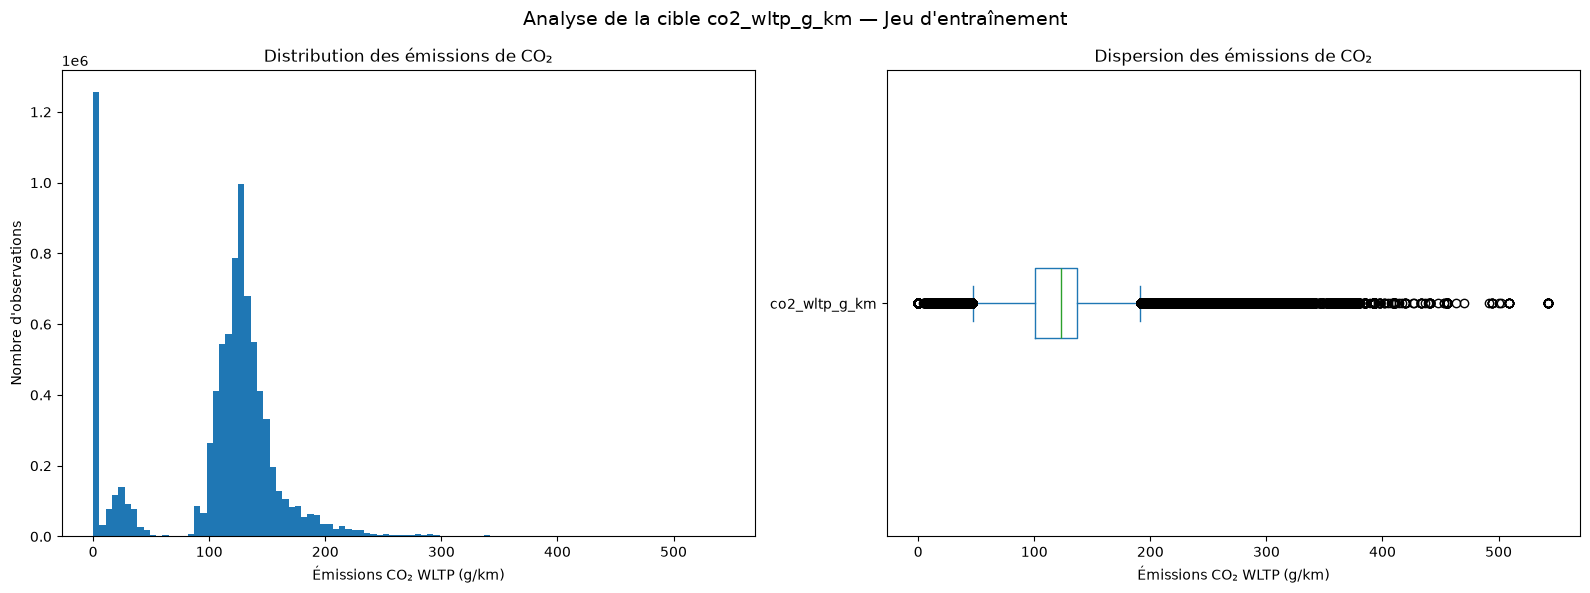

In [4]:
# ---------------------------------------------------------------------
# 2.3 - Visualisation de la distribution de y_train
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt


fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
)


# ---------------------------------------------------------------------
# Histogramme
# ---------------------------------------------------------------------

y_train.plot.hist(
    bins=100,
    ax=axes[0],
)

axes[0].set_title(
    "Distribution des émissions de CO₂"
)
axes[0].set_xlabel(
    "Émissions CO₂ WLTP (g/km)"
)
axes[0].set_ylabel(
    "Nombre d'observations"
)


# ---------------------------------------------------------------------
# Boxplot
# ---------------------------------------------------------------------

y_train.plot.box(
    ax=axes[1],
    vert=False,
)

axes[1].set_title(
    "Dispersion des émissions de CO₂"
)
axes[1].set_xlabel(
    "Émissions CO₂ WLTP (g/km)"
)
axes[1].set_ylabel("")


# ---------------------------------------------------------------------
# Titre général
# ---------------------------------------------------------------------

fig.suptitle(
    "Analyse de la cible co2_wltp_g_km — Jeu d'entraînement",
    fontsize=14,
)

plt.tight_layout()
plt.show()

## 3. Étude des stratégies de discrétisation de la cible

### Objectif

La transformation de `co2_wltp_g_km` en variable de classification nécessite
de définir des intervalles représentant différents niveaux d'émissions.

Le choix de ces intervalles influence directement :

- la signification métier des classes ;
- leur niveau d'équilibre ;
- la difficulté du problème de classification ;
- l'interprétation des performances du modèle.

Plusieurs stratégies de discrétisation peuvent être envisagées.

### Stratégies étudiées

**Discrétisation par intervalles réguliers**

L'étendue des émissions est divisée en intervalles de largeur comparable.

Cette approche est simple à interpréter mais ne tient pas compte de la
distribution réelle des observations.

**Discrétisation par quantiles**

Les seuils sont déterminés à partir de la distribution de `y_train` afin
d'obtenir des groupes contenant des proportions comparables d'observations.

Cette approche favorise l'équilibre statistique des classes mais les seuils
obtenus ne correspondent pas nécessairement à des niveaux d'émissions ayant
une signification métier particulière.

**Discrétisation par seuils métier**

Les classes sont définies à partir de seuils explicitement choisis pour
représenter différents niveaux d'émissions.

Cette stratégie offre une meilleure interprétabilité, mais elle peut produire
des classes déséquilibrées si les seuils sont mal adaptés à la distribution
des données.

**Approche hybride**

Une stratégie hybride peut combiner l'interprétabilité de seuils explicites
avec l'analyse de la distribution observée dans `y_train`.

### Principe de sélection

Les différentes stratégies seront comparées avant la création définitive de
la cible de classification.

Le choix final devra rechercher un compromis entre :

- interprétabilité des classes ;
- représentativité statistique ;
- équilibre des effectifs ;
- cohérence avec la distribution observée ;
- pertinence pour l'utilisation future du modèle.

Les seuils seront déterminés exclusivement à partir du jeu d'entraînement.
Le jeu Test restera exclu de cette étape.

### 3.1 — Construction et comparaison de stratégies candidates

Afin d'éviter de choisir arbitrairement les seuils de classification, plusieurs
stratégies candidates sont appliquées à `y_train` puis comparées.

Pour faciliter la comparaison, l'étude vise une classification en **5 classes**.

Trois approches sont étudiées :

1. **Intervalles réguliers**  
   L'étendue observée de la cible est divisée en 5 intervalles de même largeur.

2. **Quantiles**  
   La distribution est divisée, lorsque les valeurs le permettent, en 5 groupes
   contenant des proportions aussi proches que possible.

3. **Seuils explicites candidats**  
   Des intervalles explicites sont étudiés afin de conserver une lecture directe
   des niveaux d'émissions tout en tenant compte de la structure de la distribution.

À ce stade, ces stratégies sont uniquement des **candidates**.

Leur comparaison portera notamment sur :

- les bornes obtenues ;
- les effectifs de chaque classe ;
- la proportion représentée par chaque classe ;
- l'écart entre la classe la plus représentée et la moins représentée ;
- l'interprétabilité des intervalles.

Aucune de ces stratégies n'est encore retenue comme discrétisation définitive.

In [5]:
# ---------------------------------------------------------------------
# 3.1 - Comparaison de stratégies candidates de discrétisation
# ---------------------------------------------------------------------

n_classes = 5


# ---------------------------------------------------------------------
# 1. Stratégie A - Intervalles réguliers
# ---------------------------------------------------------------------

classes_uniform, bins_uniform = pd.cut(
    y_train,
    bins=n_classes,
    retbins=True,
    include_lowest=True,
)


# ---------------------------------------------------------------------
# 2. Stratégie B - Quantiles
# ---------------------------------------------------------------------

classes_quantile, bins_quantile = pd.qcut(
    y_train,
    q=n_classes,
    retbins=True,
    duplicates="drop",
)


# ---------------------------------------------------------------------
# 3. Stratégie C - Seuils explicites candidats
# ---------------------------------------------------------------------

bins_explicit = [
    -float("inf"),
    50,
    100,
    160,
    200,
    float("inf"),
]

classes_explicit = pd.cut(
    y_train,
    bins=bins_explicit,
    include_lowest=True,
)


# ---------------------------------------------------------------------
# 4. Fonction de synthèse
# ---------------------------------------------------------------------

def summarize_discretization(classes, strategy):
    summary = (
        classes
        .value_counts(sort=False)
        .rename("Nombre d'observations")
        .to_frame()
    )

    summary["Proportion (%)"] = (
        summary["Nombre d'observations"]
        .div(len(y_train))
        .mul(100)
        .round(2)
    )

    summary.insert(
        0,
        "Stratégie de discrétisation",
        strategy,
    )

    summary.index.name = "Intervalle CO₂ WLTP (g/km)"

    return summary.reset_index()


# ---------------------------------------------------------------------
# 5. Synthèse des trois stratégies
# ---------------------------------------------------------------------

discretization_comparison = pd.concat(
    [
        summarize_discretization(
            classes_uniform,
            "Intervalles réguliers",
        ),
        summarize_discretization(
            classes_quantile,
            "Quantiles",
        ),
        summarize_discretization(
            classes_explicit,
            "Seuils explicites candidats",
        ),
    ],
    ignore_index=True,
)


print(
    "COMPARAISON DES STRATÉGIES CANDIDATES DE DISCRÉTISATION"
)
print(
    "Cible : co2_wltp_g_km | Jeu analysé : y_train | "
    f"Nombre de classes visé : {n_classes}"
)
print("=" * 90)

display(discretization_comparison)


# ---------------------------------------------------------------------
# 6. Bornes obtenues
# ---------------------------------------------------------------------

discretization_bounds = pd.DataFrame(
    {
        "Stratégie de discrétisation": [
            "Intervalles réguliers",
            "Quantiles",
            "Seuils explicites candidats",
        ],
        "Bornes CO₂ WLTP (g/km)": [
            bins_uniform.round(2).tolist(),
            bins_quantile.round(2).tolist(),
            bins_explicit,
        ],
        "Nombre de classes obtenu": [
            len(bins_uniform) - 1,
            len(bins_quantile) - 1,
            len(bins_explicit) - 1,
        ],
    }
)


print("\nBORNES OBTENUES PAR STRATÉGIE")
print(
    "Unité des bornes : g CO₂/km | "
    "Calcul effectué exclusivement sur y_train"
)
print("=" * 90)

display(discretization_bounds)

COMPARAISON DES STRATÉGIES CANDIDATES DE DISCRÉTISATION
Cible : co2_wltp_g_km | Jeu analysé : y_train | Nombre de classes visé : 5


,Intervalle CO₂ WLTP (g/km),Stratégie de discrétisation,Nombre d'observations,Proportion (%)
0,"(-0.544, 108.6]",Intervalles réguliers,2687515,31.23
1,"(108.6, 217.2]",Intervalles réguliers,5776864,67.12
2,"(217.2, 325.8]",Intervalles réguliers,134252,1.56
3,"(325.8, 434.4]",Intervalles réguliers,7784,0.09
4,"(434.4, 543.0]",Intervalles réguliers,132,0.00
5,"(-0.001, 33.0]",Quantiles,1738499,20.20
6,"(33.0, 117.0]",Quantiles,1744952,20.27
7,"(117.0, 128.0]",Quantiles,1770000,20.57
8,"(128.0, 142.0]",Quantiles,1642507,19.08
9,"(142.0, 543.0]",Quantiles,1710589,19.88



BORNES OBTENUES PAR STRATÉGIE
Unité des bornes : g CO₂/km | Calcul effectué exclusivement sur y_train


,Stratégie de discrétisation,Bornes CO₂ WLTP (g/km),Nombre de classes obtenu
0,Intervalles réguliers,"[-0.54, 108.6, 217.2, 325.8, 434.4, 543.0]",5
1,Quantiles,"[0.0, 33.0, 117.0, 128.0, 142.0, 543.0]",5
2,Seuils explicites candidats,"[-inf, 50, 100, 160, 200, inf]",5


### 3.2 — Étude du nombre de classes

Le nombre de classes constitue un choix de conception du problème de
classification.

L'utilisation de **5 classes** dans l'analyse précédente correspondait à une
hypothèse de travail permettant de comparer plusieurs stratégies de
discrétisation à granularité constante. Ce nombre n'est pas encore considéré
comme définitif.

Cette étape étudie plusieurs granularités candidates :

- 3 classes ;
- 4 classes ;
- 5 classes ;
- 6 classes.

La comparaison est réalisée à partir d'une discrétisation par quantiles sur
`y_train`.

Les quantiles sont utilisés ici comme **outil de diagnostic statistique** :
ils permettent d'étudier la répartition des observations pour différents
nombres de classes sans préjuger des seuils métier qui pourront être retenus
ultérieurement.

L'analyse porte notamment sur :

- le nombre de classes effectivement obtenu ;
- les bornes générées ;
- les effectifs par classe ;
- les proportions d'observations ;
- l'équilibre entre les classes.

Cette étape ne détermine pas à elle seule le nombre définitif de classes.
Le choix final devra également tenir compte de l'interprétabilité métier et
de la pertinence des intervalles obtenus.

Le jeu Test reste exclu de cette étude.

In [6]:
# ---------------------------------------------------------------------
# 3.2 - Étude du nombre de classes
# ---------------------------------------------------------------------

candidate_class_counts = [3, 4, 5, 6]

class_count_results = []
class_count_summary = []


# ---------------------------------------------------------------------
# Comparaison des granularités candidates
# ---------------------------------------------------------------------

for requested_classes in candidate_class_counts:

    classes, bins = pd.qcut(
        y_train,
        q=requested_classes,
        retbins=True,
        duplicates="drop",
    )

    distribution = (
        classes
        .value_counts(sort=False)
        .rename("Nombre d'observations")
        .to_frame()
    )

    distribution["Proportion (%)"] = (
        distribution["Nombre d'observations"]
        .div(len(y_train))
        .mul(100)
        .round(2)
    )

    distribution.insert(
        0,
        "Nombre de classes demandé",
        requested_classes,
    )

    distribution.insert(
        1,
        "Nombre de classes obtenu",
        len(bins) - 1,
    )

    distribution.index.name = "Intervalle CO₂ WLTP (g/km)"

    class_count_results.append(
        distribution.reset_index()
    )

    proportions = distribution["Proportion (%)"]

    class_count_summary.append(
        {
            "Nombre de classes demandé": requested_classes,
            "Nombre de classes obtenu": len(bins) - 1,
            "Proportion minimale (%)": proportions.min(),
            "Proportion maximale (%)": proportions.max(),
            "Écart max-min (points de %)": (
                proportions.max() - proportions.min()
            ),
            "Bornes CO₂ WLTP (g/km)": bins.round(2).tolist(),
        }
    )


# ---------------------------------------------------------------------
# Tableau détaillé
# ---------------------------------------------------------------------

class_count_comparison = pd.concat(
    class_count_results,
    ignore_index=True,
)

print(
    "RÉPARTITION DES OBSERVATIONS SELON LE NOMBRE DE CLASSES"
)
print(
    "Méthode : quantiles | Cible : co2_wltp_g_km | "
    "Jeu analysé : y_train"
)
print("=" * 100)

display(class_count_comparison)


# ---------------------------------------------------------------------
# Tableau de synthèse
# ---------------------------------------------------------------------

class_count_summary_df = pd.DataFrame(
    class_count_summary
)

print("\nSYNTHÈSE DES GRANULARITÉS CANDIDATES")
print(
    "Méthode : quantiles | Unité des bornes : g CO₂/km | "
    "Jeu analysé : y_train"
)
print("=" * 100)

display(class_count_summary_df)

RÉPARTITION DES OBSERVATIONS SELON LE NOMBRE DE CLASSES
Méthode : quantiles | Cible : co2_wltp_g_km | Jeu analysé : y_train


,Intervalle CO₂ WLTP (g/km),Nombre de classes demandé,Nombre de classes obtenu,Nombre d'observations,Proportion (%)
0,"(-0.001, 110.0]",3,3,2873530,33.39
1,"(110.0, 131.0]",3,3,2867347,33.32
2,"(131.0, 543.0]",3,3,2865670,33.30
3,"(-0.001, 101.0]",4,4,2175842,25.28
4,"(101.0, 123.0]",4,4,2282447,26.52
5,"(123.0, 137.0]",4,4,2011302,23.37
6,"(137.0, 543.0]",4,4,2136956,24.83
7,"(-0.001, 33.0]",5,5,1738499,20.20
8,"(33.0, 117.0]",5,5,1744952,20.27
9,"(117.0, 128.0]",5,5,1770000,20.57



SYNTHÈSE DES GRANULARITÉS CANDIDATES
Méthode : quantiles | Unité des bornes : g CO₂/km | Jeu analysé : y_train


,Nombre de classes demandé,Nombre de classes obtenu,Proportion minimale (%),Proportion maximale (%),Écart max-min (points de %),Bornes CO₂ WLTP (g/km)
0,3,3,33.30,33.39,0.09,"[0.0, 110.0, 131.0, 543.0]"
1,4,4,23.37,26.52,3.15,"[0.0, 101.0, 123.0, 137.0, 543.0]"
2,5,5,19.08,20.57,1.49,"[0.0, 33.0, 117.0, 128.0, 142.0, 543.0]"
3,6,6,14.90,18.41,3.51,"[0.0, 19.0, 110.0, 123.0, 131.0, 146.0, 543.0]"


### 3.3 — Analyse multicritère du nombre de classes

L'équilibre statistique ne constitue pas à lui seul un critère suffisant pour
déterminer le nombre de classes.

Une discrétisation peut produire des classes très équilibrées tout en regroupant
dans un même intervalle des niveaux d'émissions très différents. À l'inverse,
une granularité trop fine peut créer des frontières très rapprochées et rendre
la classification inutilement sensible à de faibles variations de la cible.

Le nombre de classes doit donc être étudié selon plusieurs dimensions :

- **équilibre statistique** : éviter des classes excessivement minoritaires ;
- **granularité** : conserver suffisamment d'information sur le niveau d'émission ;
- **séparation des niveaux d'émissions** : éviter des classes couvrant des plages
  excessivement larges ;
- **interprétabilité** : permettre une lecture claire du niveau associé à chaque classe ;
- **complexité du problème de classification** : limiter une fragmentation excessive
  de la cible.

L'analyse par quantiles réalisée précédemment constitue un diagnostic de la
structure statistique de `y_train`. Elle ne définit pas encore les seuils
définitifs de classification.

L'étape suivante consiste à confronter cette structure statistique à des
intervalles d'émissions ayant une interprétation métier plus explicite.

### 3.4 — Étude de scénarios de seuils interprétables

Les discrétisations précédentes ont permis d'étudier séparément l'équilibre
statistique des classes et différentes granularités possibles.

La discrétisation par quantiles présente l'avantage de produire des classes
relativement équilibrées, mais ses frontières sont directement déterminées
par la distribution des données et ne sont pas nécessairement faciles à
interpréter.

Cette étape étudie donc plusieurs scénarios utilisant des seuils explicites
et arrondis exprimés en `g CO₂/km`.

Ces scénarios sont des **hypothèses de travail** et non des seuils
réglementaires.

Ils sont comparés selon :

- la répartition des observations ;
- la proportion de chaque classe ;
- l'équilibre entre la classe majoritaire et la classe minoritaire ;
- la largeur et la lisibilité des intervalles ;
- la capacité à distinguer différents niveaux d'émissions.

Aucun scénario n'est encore considéré comme définitif à cette étape.

In [7]:
# ---------------------------------------------------------------------
# 3.4 - Étude de scénarios de seuils interprétables
# ---------------------------------------------------------------------

candidate_scenarios = {
    "Scénario A": [
        -float("inf"),
        50,
        100,
        150,
        200,
        float("inf"),
    ],
    "Scénario B": [
        -float("inf"),
        75,
        110,
        140,
        180,
        float("inf"),
    ],
    "Scénario C": [
        -float("inf"),
        50,
        110,
        140,
        180,
        float("inf"),
    ],
}


# ---------------------------------------------------------------------
# Construction et synthèse des scénarios
# ---------------------------------------------------------------------

scenario_results = []
scenario_summary = []

for scenario_name, bins in candidate_scenarios.items():

    classes = pd.cut(
        y_train,
        bins=bins,
        include_lowest=True,
    )

    distribution = (
        classes
        .value_counts(sort=False)
        .rename("Nombre d'observations")
        .to_frame()
    )

    distribution["Proportion (%)"] = (
        distribution["Nombre d'observations"]
        .div(len(y_train))
        .mul(100)
        .round(2)
    )

    distribution.insert(
        0,
        "Scénario",
        scenario_name,
    )

    distribution.index.name = "Intervalle CO₂ WLTP (g/km)"

    scenario_results.append(
        distribution.reset_index()
    )

    proportions = distribution["Proportion (%)"]

    scenario_summary.append(
        {
            "Scénario": scenario_name,
            "Nombre de classes": len(bins) - 1,
            "Proportion minimale (%)": proportions.min(),
            "Proportion maximale (%)": proportions.max(),
            "Écart max-min (points de %)": (
                proportions.max() - proportions.min()
            ),
            "Bornes CO₂ WLTP (g/km)": bins,
        }
    )


# ---------------------------------------------------------------------
# Tableau détaillé
# ---------------------------------------------------------------------

scenario_comparison = pd.concat(
    scenario_results,
    ignore_index=True,
)

print(
    "COMPARAISON DES SCÉNARIOS DE SEUILS INTERPRÉTABLES"
)
print(
    "Cible : co2_wltp_g_km | Jeu analysé : y_train | "
    "Unité : g CO₂/km"
)
print("=" * 100)

display(scenario_comparison)


# ---------------------------------------------------------------------
# Tableau de synthèse
# ---------------------------------------------------------------------

scenario_summary_df = pd.DataFrame(
    scenario_summary
)

print("\nSYNTHÈSE DES SCÉNARIOS CANDIDATS")
print(
    "Les seuils étudiés sont des hypothèses de travail "
    "et non des seuils réglementaires."
)
print("=" * 100)

display(scenario_summary_df)

COMPARAISON DES SCÉNARIOS DE SEUILS INTERPRÉTABLES
Cible : co2_wltp_g_km | Jeu analysé : y_train | Unité : g CO₂/km


,Intervalle CO₂ WLTP (g/km),Scénario,Nombre d'observations,Proportion (%)
0,"(-inf, 50.0]",Scénario A,1840343,21.38
1,"(50.0, 100.0]",Scénario A,259840,3.02
2,"(100.0, 150.0]",Scénario A,5353060,62.20
3,"(150.0, 200.0]",Scénario A,926980,10.77
4,"(200.0, inf]",Scénario A,226324,2.63
5,"(-inf, 75.0]",Scénario B,1848612,21.48
6,"(75.0, 110.0]",Scénario B,1024918,11.91
7,"(110.0, 140.0]",Scénario B,3834496,44.55
8,"(140.0, 180.0]",Scénario B,1465709,17.03
9,"(180.0, inf]",Scénario B,432812,5.03



SYNTHÈSE DES SCÉNARIOS CANDIDATS
Les seuils étudiés sont des hypothèses de travail et non des seuils réglementaires.


,Scénario,Nombre de classes,Proportion minimale (%),Proportion maximale (%),Écart max-min (points de %),Bornes CO₂ WLTP (g/km)
0,Scénario A,5,2.63,62.20,59.57,"[-inf, 50, 100, 150, 200, inf]"
1,Scénario B,5,5.03,44.55,39.52,"[-inf, 75, 110, 140, 180, inf]"
2,Scénario C,5,5.03,44.55,39.52,"[-inf, 50, 110, 140, 180, inf]"


### 3.5 — Application du référentiel ADEME à `y_train`

Afin de disposer d'une base métier explicite, la cible `co2_wltp_g_km`
est d'abord discrétisée selon les classes CO₂ A à G du référentiel ADEME.

Cette étape ne constitue pas encore la cible définitive du modèle de
classification.

Elle permet d'évaluer, sur `y_train` :

- les effectifs de chaque classe ADEME ;
- leur proportion dans le jeu d'entraînement ;
- l'éventuel déséquilibre entre les classes ;
- la nécessité ou non d'agréger certaines classes avant l'apprentissage.

Les seuils sont appliqués tels quels afin de préserver leur interprétation
métier.

Le jeu `y_test` reste exclu de cette étape.

In [8]:
# ---------------------------------------------------------------------
# 3.5 - Application du référentiel ADEME à y_train
# ---------------------------------------------------------------------

ademe_bins = [
    -float("inf"),
    100,
    120,
    140,
    160,
    200,
    250,
    float("inf"),
]

ademe_labels = [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
]


# ---------------------------------------------------------------------
# 1. Discrétisation selon les classes ADEME
# ---------------------------------------------------------------------

y_train_ademe_class = pd.cut(
    y_train,
    bins=ademe_bins,
    labels=ademe_labels,
    include_lowest=True,
)


# ---------------------------------------------------------------------
# 2. Répartition des observations
# ---------------------------------------------------------------------

ademe_distribution = (
    y_train_ademe_class
    .value_counts(sort=False)
    .rename("Nombre d'observations")
    .to_frame()
)

ademe_distribution["Proportion (%)"] = (
    ademe_distribution["Nombre d'observations"]
    .div(len(y_train))
    .mul(100)
    .round(2)
)

ademe_distribution.index.name = "Classe ADEME"


# ---------------------------------------------------------------------
# 3. Tableau métier des classes
# ---------------------------------------------------------------------

ademe_class_reference = pd.DataFrame(
    {
        "Classe ADEME": ademe_labels,
        "Intervalle CO₂ WLTP (g/km)": [
            "≤ 100",
            "]100 ; 120]",
            "]120 ; 140]",
            "]140 ; 160]",
            "]160 ; 200]",
            "]200 ; 250]",
            "> 250",
        ],
        "Niveau d'émission": [
            "Classe A",
            "Classe B",
            "Classe C",
            "Classe D",
            "Classe E",
            "Classe F",
            "Classe G",
        ],
    }
)


# ---------------------------------------------------------------------
# 4. Fusion des informations métier et statistiques
# ---------------------------------------------------------------------

ademe_analysis = (
    ademe_class_reference
    .merge(
        ademe_distribution.reset_index(),
        on="Classe ADEME",
        how="left",
    )
)


# ---------------------------------------------------------------------
# 5. Affichage
# ---------------------------------------------------------------------

print("RÉPARTITION DE y_train SELON LE RÉFÉRENTIEL ADEME")
print(
    "Cible : co2_wltp_g_km | Jeu analysé : y_train | "
    "Unité : g CO₂/km"
)
print("=" * 100)

display(ademe_analysis)


# ---------------------------------------------------------------------
# 6. Contrôle
# ---------------------------------------------------------------------

print("\nCONTRÔLE DE LA DISCRÉTISATION")
print("=" * 100)

print(
    f"Observations classées     : "
    f"{y_train_ademe_class.notna().sum():,}"
)

print(
    f"Observations non classées : "
    f"{y_train_ademe_class.isna().sum():,}"
)

print(
    f"Total y_train             : "
    f"{len(y_train):,}"
)

RÉPARTITION DE y_train SELON LE RÉFÉRENTIEL ADEME
Cible : co2_wltp_g_km | Jeu analysé : y_train | Unité : g CO₂/km


,Classe ADEME,Intervalle CO₂ WLTP (g/km),Niveau d'émission,Nombre d'observations,Proportion (%)
0,A,≤ 100,Classe A,2100183,24.40
1,B,]100 ; 120],Classe B,1925350,22.37
2,C,]120 ; 140],Classe C,2682493,31.17
3,D,]140 ; 160],Classe D,1138641,13.23
4,E,]160 ; 200],Classe E,533556,6.20
5,F,]200 ; 250],Classe F,165326,1.92
6,G,> 250,Classe G,60998,0.71



CONTRÔLE DE LA DISCRÉTISATION
Observations classées     : 8,606,547
Observations non classées : 0
Total y_train             : 8,606,547


### 3.6 — Création définitive des cibles de classification Train et Test

La classification retenue repose sur les **7 classes CO₂ du référentiel ADEME**,
ordonnées de A à G.

Les mêmes seuils sont appliqués à `y_train` et `y_test` afin de créer :

- `y_train_class` : cible de classification utilisée pour l'apprentissage ;
- `y_test_class` : cible de classification utilisée pour l'évaluation finale.

Les variables continues d'origine `y_train` et `y_test` sont conservées.

Les classes sont interprétées comme suit :

- **A** : très faibles émissions ;
- **B** : faibles émissions ;
- **C** : émissions modérées ;
- **D** : émissions intermédiaires ;
- **E** : émissions élevées ;
- **F** : très fortes émissions ;
- **G** : émissions extrêmement élevées.

Les seuils ADEME sont appliqués à l'identique sur Train et Test.
Aucun seuil n'est recalculé à partir du jeu Test.

In [9]:
# ---------------------------------------------------------------------
# 3.6 - Création définitive des cibles de classification
# ---------------------------------------------------------------------

# Création des cibles Train et Test
y_train_class = pd.cut(
    y_train,
    bins=ademe_bins,
    labels=ademe_labels,
    include_lowest=True,
)

y_test_class = pd.cut(
    y_test,
    bins=ademe_bins,
    labels=ademe_labels,
    include_lowest=True,
)


# ---------------------------------------------------------------------
# Contrôles de cohérence
# ---------------------------------------------------------------------

if len(y_train_class) != len(y_train):
    raise ValueError(
        "Incohérence entre y_train et y_train_class."
    )

if len(y_test_class) != len(y_test):
    raise ValueError(
        "Incohérence entre y_test et y_test_class."
    )

if y_train_class.isna().any():
    raise ValueError(
        "y_train_class contient des valeurs non classées."
    )

if y_test_class.isna().any():
    raise ValueError(
        "y_test_class contient des valeurs non classées."
    )


# ---------------------------------------------------------------------
# Libellés métier
# ---------------------------------------------------------------------

class_business_labels = {
    "A": "Très faibles émissions",
    "B": "Faibles émissions",
    "C": "Émissions modérées",
    "D": "Émissions intermédiaires",
    "E": "Émissions élevées",
    "F": "Très fortes émissions",
    "G": "Émissions extrêmement élevées",
}

class_intervals = {
    "A": "≤ 100",
    "B": "]100 ; 120]",
    "C": "]120 ; 140]",
    "D": "]140 ; 160]",
    "E": "]160 ; 200]",
    "F": "]200 ; 250]",
    "G": "> 250",
}


# ---------------------------------------------------------------------
# Distribution Train / Test
# ---------------------------------------------------------------------

class_distribution_train_test = pd.concat(
    [
        y_train_class.value_counts(sort=False).rename(
            "Train - Nombre d'observations"
        ),
        (
            y_train_class
            .value_counts(normalize=True, sort=False)
            .mul(100)
        ).rename("Train - Proportion (%)"),
        y_test_class.value_counts(sort=False).rename(
            "Test - Nombre d'observations"
        ),
        (
            y_test_class
            .value_counts(normalize=True, sort=False)
            .mul(100)
        ).rename("Test - Proportion (%)"),
    ],
    axis=1,
).round(2)

class_distribution_train_test.index.name = "Classe ADEME"

class_distribution_train_test.insert(
    0,
    "Intervalle CO₂ WLTP (g/km)",
    [
        class_intervals[class_name]
        for class_name in ademe_labels
    ],
)

class_distribution_train_test.insert(
    1,
    "Niveau d'émission",
    [
        class_business_labels[class_name]
        for class_name in ademe_labels
    ],
)


# ---------------------------------------------------------------------
# Affichage
# ---------------------------------------------------------------------

print("CIBLES DE CLASSIFICATION TRAIN / TEST")
print(
    "Référentiel : ADEME | Classes : A à G | "
    "Cible d'origine : co2_wltp_g_km"
)
print("=" * 110)

display(class_distribution_train_test)


print("\nCONTRÔLE DES CIBLES")
print("=" * 110)

print(
    f"y_train       : {len(y_train):,} observations"
)

print(
    f"y_train_class : {len(y_train_class):,} observations"
)

print(
    f"y_test        : {len(y_test):,} observations"
)

print(
    f"y_test_class  : {len(y_test_class):,} observations"
)

print(
    f"\nValeurs non classées dans y_train_class : "
    f"{y_train_class.isna().sum():,}"
)

print(
    f"Valeurs non classées dans y_test_class  : "
    f"{y_test_class.isna().sum():,}"
)

print(
    "\n✅ Les mêmes seuils ADEME sont appliqués au Train et au Test."
)

print(
    "✅ Les cibles de classification y_train_class et y_test_class sont créées."
)

print(
    "✅ Les cibles continues y_train et y_test sont conservées."
)

CIBLES DE CLASSIFICATION TRAIN / TEST
Référentiel : ADEME | Classes : A à G | Cible d'origine : co2_wltp_g_km


,Intervalle CO₂ WLTP (g/km),Niveau d'émission,Train - Nombre d'observations,Train - Proportion (%),Test - Nombre d'observations,Test - Proportion (%)
Classe ADEME,,,,,,
A,≤ 100,Très faibles émissions,2100183,24.40,524232,24.36
B,]100 ; 120],Faibles émissions,1925350,22.37,482347,22.42
C,]120 ; 140],Émissions modérées,2682493,31.17,670960,31.18
D,]140 ; 160],Émissions intermédiaires,1138641,13.23,284593,13.23
E,]160 ; 200],Émissions élevées,533556,6.20,133221,6.19
F,]200 ; 250],Très fortes émissions,165326,1.92,41154,1.91
G,> 250,Émissions extrêmement élevées,60998,0.71,15130,0.70



CONTRÔLE DES CIBLES
y_train       : 8,606,547 observations
y_train_class : 8,606,547 observations
y_test        : 2,151,637 observations
y_test_class  : 2,151,637 observations

Valeurs non classées dans y_train_class : 0
Valeurs non classées dans y_test_class  : 0

✅ Les mêmes seuils ADEME sont appliqués au Train et au Test.
✅ Les cibles de classification y_train_class et y_test_class sont créées.
✅ Les cibles continues y_train et y_test sont conservées.


## 4 — Modélisation de classification

La cible `co2_wltp_g_km` a été transformée en une cible de classification
ordinale `y_train_class` comportant **7 classes d'émissions A à G**.

La modélisation vise désormais à prédire la classe d'émission d'un véhicule
à partir des variables explicatives prétraitées de `X_train`.

Le protocole conserve la séparation Train / Test définie en amont :

- `X_train` et `y_train_class` sont utilisés pour l'apprentissage et la
  sélection des modèles ;
- `X_test` et `y_test_class` restent réservés à l'évaluation finale du modèle
  sélectionné.

Une attention particulière sera portée au déséquilibre des classes, notamment
aux classes F et G, moins représentées dans le jeu d'entraînement.

La comparaison des modèles reposera sur plusieurs métriques complémentaires
afin de ne pas privilégier uniquement les classes majoritaires.

### 4.1 — Métriques d'évaluation

La cible comporte 7 classes dont les fréquences sont différentes. L'Accuracy
ne suffit donc pas à évaluer correctement les modèles : une bonne performance
sur les classes majoritaires pourrait masquer de mauvaises performances sur
les classes moins représentées.

La métrique principale retenue pour la comparaison des modèles est le
**F1-score macro (`F1-macro`)**.

Cette métrique calcule le F1-score indépendamment pour chaque classe puis
effectue leur moyenne sans pondération par les effectifs. Chaque classe
contribue ainsi de manière équivalente au score global.

Les métriques suivantes seront utilisées conjointement :

- **Accuracy** : proportion globale de prédictions correctes ;
- **Balanced Accuracy** : moyenne des rappels obtenus pour chaque classe ;
- **F1-macro** : métrique principale de comparaison des modèles ;
- **F1-weighted** : F1-score pondéré par les effectifs des classes.

L'analyse finale sera complétée par le rapport de classification et la matrice
de confusion afin d'étudier les performances individuelles des classes A à G.

### 4.2 — Modèles candidats et stratégie de comparaison

La comparaison initiale porte sur trois familles de modèles de classification
complémentaires :

1. **Logistic Regression**
   - modèle linéaire utilisé comme baseline ;
   - fournit un point de référence simple pour mesurer l'intérêt des modèles
     non linéaires.

2. **Random Forest Classifier**
   - modèle d'ensemble basé sur plusieurs arbres de décision ;
   - permet de modéliser des relations non linéaires et des interactions entre
     les variables.

3. **HistGradientBoosting Classifier**
   - modèle de boosting utilisant une représentation histogramme des variables ;
   - particulièrement adapté aux jeux de données tabulaires de grande taille.

Compte tenu du volume du jeu d'entraînement, la comparaison initiale n'est pas
réalisée directement sur l'intégralité de `X_train`.

Un échantillon d'entraînement est constitué à partir du Train en conservant la
distribution des classes A à G.

Le jeu Test final (`X_test`, `y_test_class`) reste totalement exclu de cette
phase de comparaison et de sélection des modèles.

Les modèles seront comparés principalement à partir du **F1-macro**, complété
par l'Accuracy, la Balanced Accuracy et le F1-weighted.

### 4.3 — Construction de l'échantillon d'entraînement pour la comparaison

La comparaison initiale des modèles est réalisée sur un sous-ensemble de
`X_train` afin de maîtriser le coût de calcul.

L'échantillonnage est **stratifié sur `y_train_class`** afin de préserver la
répartition des classes A à G observée dans le jeu d'entraînement.

Un échantillon de **500 000 observations** est utilisé pour cette première
comparaison.

Cet échantillon est exclusivement extrait du Train.

Le jeu Test final n'intervient ni dans l'échantillonnage, ni dans
l'entraînement, ni dans la sélection initiale des modèles.

In [10]:
# ---------------------------------------------------------------------
# 4.3 - Échantillon stratifié pour la comparaison des modèles
# ---------------------------------------------------------------------

comparison_sample_size = 500_000

if comparison_sample_size > len(X_train):
    raise ValueError(
        "La taille de l'échantillon dépasse le nombre "
        "d'observations disponibles dans X_train."
    )


# ---------------------------------------------------------------------
# Échantillonnage stratifié exclusivement à partir du Train
# ---------------------------------------------------------------------

X_train_comparison, _, y_train_class_comparison, _ = train_test_split(
    X_train,
    y_train_class,
    train_size=comparison_sample_size,
    stratify=y_train_class,
    random_state=42,
)


# ---------------------------------------------------------------------
# Distribution de l'échantillon
# ---------------------------------------------------------------------

comparison_sample_distribution = pd.concat(
    [
        y_train_class.value_counts(
            normalize=True,
            sort=False,
        ).mul(100).rename("Train - Proportion (%)"),

        y_train_class_comparison.value_counts(
            sort=False,
        ).rename("Échantillon - Nombre d'observations"),

        y_train_class_comparison.value_counts(
            normalize=True,
            sort=False,
        ).mul(100).rename("Échantillon - Proportion (%)"),
    ],
    axis=1,
).round(2)

comparison_sample_distribution.index.name = "Classe ADEME"


# ---------------------------------------------------------------------
# Ajout des libellés métier
# ---------------------------------------------------------------------

comparison_sample_distribution.insert(
    0,
    "Niveau d'émission",
    [
        class_business_labels[class_name]
        for class_name in ademe_labels
    ],
)


# ---------------------------------------------------------------------
# Affichage
# ---------------------------------------------------------------------

print("ÉCHANTILLON D'ENTRAÎNEMENT POUR LA COMPARAISON DES MODÈLES")
print(
    "Source : X_train / y_train_class | "
    "Méthode : échantillonnage stratifié"
)
print("=" * 110)

print(
    f"Train disponible       : {len(X_train):,} observations"
)

print(
    f"Échantillon comparaison : "
    f"{len(X_train_comparison):,} observations"
)

print(
    f"Nombre de variables     : "
    f"{X_train_comparison.shape[1]}"
)

print()

display(comparison_sample_distribution)


# ---------------------------------------------------------------------
# Contrôles
# ---------------------------------------------------------------------

assert len(X_train_comparison) == comparison_sample_size
assert len(y_train_class_comparison) == comparison_sample_size
assert X_train_comparison.index.equals(
    y_train_class_comparison.index
)

print("\nCONTRÔLE")
print("=" * 110)

print("✅ Taille de l'échantillon conforme.")
print("✅ Correspondance X / y conservée.")
print("✅ Stratification réalisée sur les classes A à G.")
print("✅ Le Test final n'a pas été utilisé.")

ÉCHANTILLON D'ENTRAÎNEMENT POUR LA COMPARAISON DES MODÈLES
Source : X_train / y_train_class | Méthode : échantillonnage stratifié
Train disponible       : 8,606,547 observations
Échantillon comparaison : 500,000 observations
Nombre de variables     : 41



,Niveau d'émission,Train - Proportion (%),Échantillon - Nombre d'observations,Échantillon - Proportion (%)
Classe ADEME,,,,
A,Très faibles émissions,24.40,122011,24.40
B,Faibles émissions,22.37,111854,22.37
C,Émissions modérées,31.17,155840,31.17
D,Émissions intermédiaires,13.23,66150,13.23
E,Émissions élevées,6.20,30997,6.20
F,Très fortes émissions,1.92,9604,1.92
G,Émissions extrêmement élevées,0.71,3544,0.71



CONTRÔLE
✅ Taille de l'échantillon conforme.
✅ Correspondance X / y conservée.
✅ Stratification réalisée sur les classes A à G.
✅ Le Test final n'a pas été utilisé.


### 4.4 — Baseline de classification : Logistic Regression

La première référence de classification est une `LogisticRegression`.

Ce modèle joue le rôle de **baseline linéaire** et permet d'établir un premier
niveau de performance avant l'utilisation de modèles non linéaires plus
complexes.

Cette première expérimentation est réalisée sur l'échantillon stratifié issu
du jeu Train.

Les performances calculées sur les données d'entraînement constituent un
**diagnostic initial d'ajustement**. Elles ne sont pas utilisées pour sélectionner
le modèle final.

La comparaison des modèles sera ensuite réalisée sur un jeu de validation
distinct des observations utilisées pour leur apprentissage.

Le `F1-macro` constitue la métrique principale de comparaison, complétée par
`l'Accuracy`, la `Balanced Accuracy` et le `F1-weighted`.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)

# ---------------------------------------------------------------------
# 4.4 - Baseline Logistic Regression
# ---------------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
)


# ---------------------------------------------------------------------
# Entraînement
# ---------------------------------------------------------------------

logistic_model.fit(
    X_train_comparison,
    y_train_class_comparison,
)


# ---------------------------------------------------------------------
# Prédictions
# ---------------------------------------------------------------------

y_train_logistic_pred = logistic_model.predict(
    X_train_comparison
)


# ---------------------------------------------------------------------
# Métriques
# ---------------------------------------------------------------------

logistic_results = {
    "Modèle": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_train_class_comparison,
        y_train_logistic_pred,
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_train_class_comparison,
        y_train_logistic_pred,
    ),
    "F1-macro": f1_score(
        y_train_class_comparison,
        y_train_logistic_pred,
        average="macro",
    ),
    "F1-weighted": f1_score(
        y_train_class_comparison,
        y_train_logistic_pred,
        average="weighted",
    ),
}


# ---------------------------------------------------------------------
# Affichage
# ---------------------------------------------------------------------

logistic_results_df = pd.DataFrame(
    [logistic_results]
)

print("PERFORMANCES DE LA BASELINE LOGISTIC REGRESSION")
print(
    "Jeu évalué : échantillon stratifié Train | "
    "Cible : y_train_class"
)
print("=" * 100)

display(
    logistic_results_df.round(4)
)

PERFORMANCES DE LA BASELINE LOGISTIC REGRESSION
Jeu évalué : échantillon stratifié Train | Cible : y_train_class


,Modèle,Accuracy,Balanced Accuracy,F1-macro,F1-weighted
0,Logistic Regression,0.8271,0.8135,0.8293,0.8275


### 4.5 — Random Forest Classifier : diagnostic initial

Le deuxième modèle évalué est un `RandomForestClassifier`.

Contrairement à la Logistic Regression, le Random Forest permet de modéliser
des relations non linéaires ainsi que des interactions complexes entre les
variables explicatives.

Cette première expérimentation utilise les paramètres standards du modèle,
avec un `random_state` fixé pour assurer la reproductibilité et l'utilisation
des ressources CPU disponibles pour paralléliser l'entraînement.

Comme pour la baseline, cette étape constitue un **diagnostic initial
d'ajustement sur les données d'entraînement**.

Les performances obtenues à cette étape ne permettent pas à elles seules
d'évaluer la capacité de généralisation du modèle.

La comparaison destinée à la sélection des modèles sera réalisée dans l'étape
suivante sur un jeu de validation distinct.

Le `F1-macro` reste la métrique principale de comparaison.

In [12]:
from sklearn.ensemble import RandomForestClassifier

# ---------------------------------------------------------------------
# 4.5 - Random Forest Classifier
# ---------------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
)


# ---------------------------------------------------------------------
# Entraînement
# ---------------------------------------------------------------------

random_forest_model.fit(
    X_train_comparison,
    y_train_class_comparison,
)


# ---------------------------------------------------------------------
# Prédictions
# ---------------------------------------------------------------------

y_train_random_forest_pred = random_forest_model.predict(
    X_train_comparison
)


# ---------------------------------------------------------------------
# Métriques
# ---------------------------------------------------------------------

random_forest_results = {
    "Modèle": "Random Forest",
    "Accuracy": accuracy_score(
        y_train_class_comparison,
        y_train_random_forest_pred,
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_train_class_comparison,
        y_train_random_forest_pred,
    ),
    "F1-macro": f1_score(
        y_train_class_comparison,
        y_train_random_forest_pred,
        average="macro",
    ),
    "F1-weighted": f1_score(
        y_train_class_comparison,
        y_train_random_forest_pred,
        average="weighted",
    ),
}


# ---------------------------------------------------------------------
# Comparaison avec la baseline
# ---------------------------------------------------------------------

classification_model_comparison = pd.DataFrame(
    [
        logistic_results,
        random_forest_results,
    ]
)

print("COMPARAISON DES MODÈLES DE CLASSIFICATION")
print(
    "Jeu évalué : échantillon stratifié Train | "
    "Observations : "
    f"{len(X_train_comparison):,}"
)
print("=" * 100)

display(
    classification_model_comparison
    .sort_values(
        by="F1-macro",
        ascending=False,
    )
    .reset_index(drop=True)
    .round(4)
)

COMPARAISON DES MODÈLES DE CLASSIFICATION
Jeu évalué : échantillon stratifié Train | Observations : 500,000


,Modèle,Accuracy,Balanced Accuracy,F1-macro,F1-weighted
0,Random Forest,0.9980,0.9986,0.9986,0.9980
1,Logistic Regression,0.8271,0.8135,0.8293,0.8275


### 4.6 — Séparation Train / Validation pour la comparaison des modèles

Les premières expérimentations ont évalué les modèles directement sur les
observations utilisées pour leur entraînement.

Cette évaluation permet d'observer leur capacité d'ajustement mais ne permet
pas d'estimer correctement leur capacité de généralisation.

Le score très élevé obtenu par le Random Forest sur son jeu d'entraînement
illustre notamment la nécessité d'une évaluation sur des observations non
utilisées pendant l'apprentissage.

L'échantillon stratifié de modélisation est donc séparé en deux sous-ensembles :

- **80 %** pour l'entraînement des modèles ;
- **20 %** pour leur validation et leur comparaison.

La séparation reste stratifiée selon les classes A à G afin de préserver leur
distribution.

Le jeu Test final reste totalement indépendant de cette étape et ne sera
utilisé qu'après la sélection et l'optimisation du modèle final.

In [13]:
# ---------------------------------------------------------------------
# 4.6 - Séparation Train / Validation
# ---------------------------------------------------------------------

(
    X_train_model,
    X_validation,
    y_train_class_model,
    y_validation_class,
) = train_test_split(
    X_train_comparison,
    y_train_class_comparison,
    test_size=0.20,
    stratify=y_train_class_comparison,
    random_state=42,
)


# ---------------------------------------------------------------------
# Distribution des classes
# ---------------------------------------------------------------------

train_validation_distribution = pd.concat(
    [
        y_train_class_model
        .value_counts(normalize=True, sort=False)
        .mul(100)
        .rename("Train modélisation - Proportion (%)"),

        y_validation_class
        .value_counts(normalize=True, sort=False)
        .mul(100)
        .rename("Validation - Proportion (%)"),
    ],
    axis=1,
).round(2)

train_validation_distribution.index.name = "Classe ADEME"

train_validation_distribution.insert(
    0,
    "Niveau d'émission",
    [
        class_business_labels[class_name]
        for class_name in ademe_labels
    ],
)


# ---------------------------------------------------------------------
# Affichage
# ---------------------------------------------------------------------

print("SÉPARATION TRAIN / VALIDATION")
print(
    "Source : échantillon stratifié de comparaison | "
    "Cible : y_train_class"
)
print("=" * 105)

print(
    f"Échantillon initial     : "
    f"{len(X_train_comparison):,} observations"
)

print(
    f"Train modélisation      : "
    f"{len(X_train_model):,} observations"
)

print(
    f"Validation              : "
    f"{len(X_validation):,} observations"
)

print()

display(train_validation_distribution)


# ---------------------------------------------------------------------
# Contrôles
# ---------------------------------------------------------------------

assert len(X_train_model) == len(y_train_class_model)
assert len(X_validation) == len(y_validation_class)

assert X_train_model.index.equals(
    y_train_class_model.index
)

assert X_validation.index.equals(
    y_validation_class.index
)

assert set(X_train_model.index).isdisjoint(
    X_validation.index
)


print("\nCONTRÔLE")
print("=" * 105)

print("✅ Correspondance X / y conservée.")
print("✅ Train modélisation et Validation sont disjoints.")
print("✅ Stratification conservée pour les classes A à G.")
print("✅ Le Test final reste totalement exclu.")

SÉPARATION TRAIN / VALIDATION
Source : échantillon stratifié de comparaison | Cible : y_train_class
Échantillon initial     : 500,000 observations
Train modélisation      : 400,000 observations
Validation              : 100,000 observations



,Niveau d'émission,Train modélisation - Proportion (%),Validation - Proportion (%)
Classe ADEME,,,
A,Très faibles émissions,24.40,24.40
B,Faibles émissions,22.37,22.37
C,Émissions modérées,31.17,31.17
D,Émissions intermédiaires,13.23,13.23
E,Émissions élevées,6.20,6.20
F,Très fortes émissions,1.92,1.92
G,Émissions extrêmement élevées,0.71,0.71



CONTRÔLE
✅ Correspondance X / y conservée.
✅ Train modélisation et Validation sont disjoints.
✅ Stratification conservée pour les classes A à G.
✅ Le Test final reste totalement exclu.


### 4.7 — Comparaison des modèles sur le jeu de validation

Les modèles candidats sont entraînés sur le même jeu de **Train modélisation**
et évalués sur le même jeu de **Validation**.

Cette séparation permet de comparer leur capacité de généralisation sur des
observations qui n'ont pas été utilisées pendant leur apprentissage.

Trois modèles sont comparés :

1. **Logistic Regression** — baseline linéaire ;
2. **Random Forest Classifier** — modèle d'ensemble basé sur des arbres ;
3. **HistGradientBoosting Classifier** — modèle de boosting adapté aux données
   tabulaires de grande taille.

Les modèles sont évalués dans un premier temps sans recherche
d'hyperparamètres afin d'établir une comparaison initiale cohérente dans les
mêmes conditions expérimentales.

La métrique principale de comparaison est le **F1-macro**, afin d'accorder le
même poids aux performances des classes A à G, indépendamment de leurs
effectifs respectifs.

Les métriques complémentaires sont :

- **Accuracy** ;
- **Balanced Accuracy** ;
- **F1-weighted**.

Cette comparaison constitue une **présélection des modèles candidats**.

Les résultats de validation permettent d'identifier les modèles les plus
prometteurs avant l'analyse détaillée de leurs performances par classe et,
si nécessaire, l'optimisation de leurs hyperparamètres.

Le modèle final n'est donc pas encore sélectionné à cette étape.

Le jeu Test final reste totalement exclu de cette comparaison.

In [14]:
from sklearn.ensemble import HistGradientBoostingClassifier

# ---------------------------------------------------------------------
# 4.7 - Comparaison des modèles sur le jeu de validation
# ---------------------------------------------------------------------

classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=42,
    ),
}


# ---------------------------------------------------------------------
# Entraînement et évaluation
# ---------------------------------------------------------------------

validation_results = []

for model_name, model in classification_models.items():

    print(f"Entraînement : {model_name}...")

    model.fit(
        X_train_model,
        y_train_class_model,
    )

    y_validation_pred = model.predict(
        X_validation
    )

    validation_results.append(
        {
            "Modèle": model_name,

            "Accuracy": accuracy_score(
                y_validation_class,
                y_validation_pred,
            ),

            "Balanced Accuracy": balanced_accuracy_score(
                y_validation_class,
                y_validation_pred,
            ),

            "F1-macro": f1_score(
                y_validation_class,
                y_validation_pred,
                average="macro",
            ),

            "F1-weighted": f1_score(
                y_validation_class,
                y_validation_pred,
                average="weighted",
            ),
        }
    )

    print(f"✅ {model_name} terminé.")


# ---------------------------------------------------------------------
# Tableau comparatif
# ---------------------------------------------------------------------

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values(
        by="F1-macro",
        ascending=False,
    )
    .reset_index(drop=True)
)


print("\nCOMPARAISON DES MODÈLES DE CLASSIFICATION")
print(
    "Entraînement : Train modélisation | "
    "Évaluation : Validation | "
    "Métrique principale : F1-macro"
)
print("=" * 110)

display(
    validation_results_df.round(4)
)

Entraînement : Logistic Regression...
✅ Logistic Regression terminé.
Entraînement : Random Forest...
✅ Random Forest terminé.
Entraînement : HistGradientBoosting...
✅ HistGradientBoosting terminé.

COMPARAISON DES MODÈLES DE CLASSIFICATION
Entraînement : Train modélisation | Évaluation : Validation | Métrique principale : F1-macro


,Modèle,Accuracy,Balanced Accuracy,F1-macro,F1-weighted
0,Random Forest,0.9885,0.9839,0.9849,0.9885
1,HistGradientBoosting,0.9718,0.9653,0.9635,0.9718
2,Logistic Regression,0.8251,0.8105,0.8269,0.8255


### 4.8 — Analyse détaillée des performances par classe

La comparaison sur le jeu de Validation positionne le
`RandomForestClassifier` et le `HistGradientBoostingClassifier` comme les deux
modèles les plus performants parmi les modèles candidats.

Les métriques globales ne suffisent toutefois pas à vérifier que leurs
performances sont homogènes sur l'ensemble des niveaux d'émission.

Cette étape analyse donc leurs performances individuellement pour chacune des
classes ADEME A à G à partir des métriques suivantes :

- **Precision** : proportion de prédictions correctes parmi les observations
  prédites dans la classe ;
- **Recall** : proportion des observations réelles de la classe correctement
  identifiées ;
- **F1-score** : moyenne harmonique de la Precision et du Recall ;
- **Nombre d'observations** : effectif réel de la classe dans le jeu de
  Validation.

Une attention particulière est portée aux classes **F** et **G**, moins
représentées dans les données d'entraînement.

Cette analyse est réalisée exclusivement sur le jeu de Validation.

Le jeu Test final reste exclu et aucun modèle définitif n'est encore
sélectionné à cette étape.

In [15]:
from sklearn.metrics import classification_report

# ---------------------------------------------------------------------
# 4.8 - Analyse détaillée des performances par classe
# ---------------------------------------------------------------------

selected_models = {
    "Random Forest": classification_models["Random Forest"],
    "HistGradientBoosting": classification_models["HistGradientBoosting"],
}

classification_reports = {}


# ---------------------------------------------------------------------
# Rapports de classification
# ---------------------------------------------------------------------

for model_name, model in selected_models.items():

    y_validation_pred = model.predict(X_validation)

    report = classification_report(
        y_validation_class,
        y_validation_pred,
        labels=ademe_labels,
        output_dict=True,
        zero_division=0,
    )

    report_df = (
        pd.DataFrame(report)
        .T
        .loc[
            ademe_labels,
            ["precision", "recall", "f1-score", "support"],
        ]
        .rename(
            columns={
                "precision": "Precision",
                "recall": "Recall",
                "f1-score": "F1-score",
                "support": "Nombre d'observations",
            }
        )
    )

    report_df.insert(
        0,
        "Niveau d'émission",
        [
            class_business_labels[class_name]
            for class_name in ademe_labels
        ],
    )

    classification_reports[model_name] = report_df


# ---------------------------------------------------------------------
# Affichage
# ---------------------------------------------------------------------

for model_name, report_df in classification_reports.items():

    print(
        f"\nPERFORMANCES PAR CLASSE — {model_name.upper()}"
    )
    print(
        "Jeu évalué : Validation | "
        "Référentiel : ADEME | Classes : A à G"
    )
    print("=" * 105)

    display(
        report_df.round(
            {
                "Precision": 4,
                "Recall": 4,
                "F1-score": 4,
                "Nombre d'observations": 0,
            }
        )
    )


PERFORMANCES PAR CLASSE — RANDOM FOREST
Jeu évalué : Validation | Référentiel : ADEME | Classes : A à G


,Niveau d'émission,Precision,Recall,F1-score,Nombre d'observations
A,Très faibles émissions,0.9986,0.9986,0.9986,24402.0
B,Faibles émissions,0.9866,0.9897,0.9882,22371.0
C,Émissions modérées,0.9878,0.9852,0.9865,31168.0
D,Émissions intermédiaires,0.9788,0.9800,0.9794,13230.0
E,Émissions élevées,0.9806,0.9842,0.9824,6199.0
F,Très fortes émissions,0.9868,0.9750,0.9809,1921.0
G,Émissions extrêmement élevées,0.9815,0.9746,0.9781,709.0



PERFORMANCES PAR CLASSE — HISTGRADIENTBOOSTING
Jeu évalué : Validation | Référentiel : ADEME | Classes : A à G


,Niveau d'émission,Precision,Recall,F1-score,Nombre d'observations
A,Très faibles émissions,0.9964,0.9968,0.9966,24402.0
B,Faibles émissions,0.9619,0.9746,0.9682,22371.0
C,Émissions modérées,0.9739,0.9588,0.9663,31168.0
D,Émissions intermédiaires,0.9502,0.9590,0.9546,13230.0
E,Émissions élevées,0.9545,0.9640,0.9592,6199.0
F,Très fortes émissions,0.9636,0.9516,0.9576,1921.0
G,Émissions extrêmement élevées,0.9323,0.9520,0.9421,709.0


### 4.9 — Analyse des erreurs par matrice de confusion

Les performances par classe montrent que le `RandomForestClassifier` obtient
les meilleurs résultats sur l'ensemble des classes ADEME, y compris sur les
classes minoritaires F et G.

La classification possède toutefois une structure **ordinale** : les classes
A à G correspondent à des niveaux croissants d'émissions de CO₂.

L'analyse des seules métriques Precision, Recall et F1-score ne permet pas
d'identifier vers quelles classes sont orientées les erreurs de prédiction.

Les matrices de confusion sont donc utilisées pour analyser la nature de ces
erreurs et déterminer notamment si les confusions se produisent principalement
entre des classes d'émission voisines.

Une attention particulière est portée aux erreurs conduisant à une
**sous-estimation du niveau d'émission**, par exemple une observation réelle
de classe G prédite F.

Les matrices sont calculées exclusivement sur le jeu de Validation.

Le jeu Test final reste exclu de cette analyse.


MATRICE DE CONFUSION — RANDOM FOREST
Jeu évalué : Validation | Lignes : classes réelles | Colonnes : classes prédites


Classe prédite,A,B,C,D,E,F,G
Classe réelle,,,,,,,
A,24369,22,0,4,3,3,1
B,19,22141,204,5,2,0,0
C,2,268,30706,184,8,0,0
D,3,9,172,12966,80,0,0
E,3,2,1,83,6101,9,0
F,5,0,0,5,26,1873,12
G,2,0,1,0,2,13,691



MATRICE DE CONFUSION NORMALISÉE (%)
Lecture : proportion des observations de chaque classe réelle répartie entre les classes prédites


Classe prédite,A,B,C,D,E,F,G
Classe réelle,,,,,,,
A,99.86,0.09,0.00,0.02,0.01,0.01,0.00
B,0.08,98.97,0.91,0.02,0.01,0.00,0.00
C,0.01,0.86,98.52,0.59,0.03,0.00,0.00
D,0.02,0.07,1.30,98.00,0.60,0.00,0.00
E,0.05,0.03,0.02,1.34,98.42,0.15,0.00
F,0.26,0.00,0.00,0.26,1.35,97.50,0.62
G,0.28,0.00,0.14,0.00,0.28,1.83,97.46


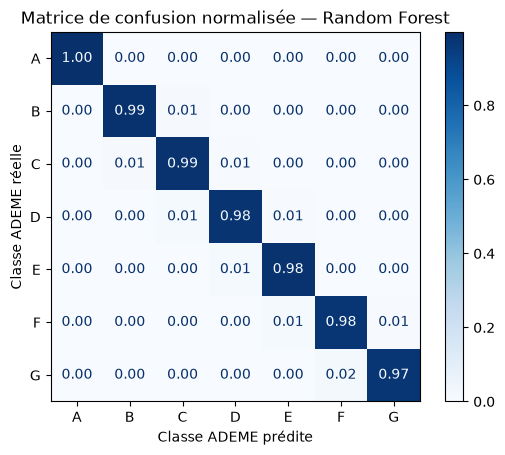


MATRICE DE CONFUSION — HISTGRADIENTBOOSTING
Jeu évalué : Validation | Lignes : classes réelles | Colonnes : classes prédites


Classe prédite,A,B,C,D,E,F,G
Classe réelle,,,,,,,
A,24325,48,2,4,6,8,9
B,54,21803,453,36,23,2,0
C,7,799,29883,455,19,3,2
D,10,14,336,12688,168,6,8
E,10,1,11,162,5976,33,6
F,6,1,0,8,54,1828,24
G,2,0,0,0,15,17,675



MATRICE DE CONFUSION NORMALISÉE (%)
Lecture : proportion des observations de chaque classe réelle répartie entre les classes prédites


Classe prédite,A,B,C,D,E,F,G
Classe réelle,,,,,,,
A,99.68,0.20,0.01,0.02,0.02,0.03,0.04
B,0.24,97.46,2.02,0.16,0.10,0.01,0.00
C,0.02,2.56,95.88,1.46,0.06,0.01,0.01
D,0.08,0.11,2.54,95.90,1.27,0.05,0.06
E,0.16,0.02,0.18,2.61,96.40,0.53,0.10
F,0.31,0.05,0.00,0.42,2.81,95.16,1.25
G,0.28,0.00,0.00,0.00,2.12,2.40,95.20


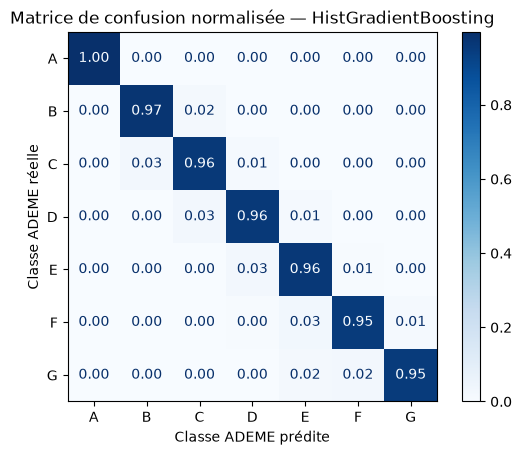

In [16]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ---------------------------------------------------------------------
# 4.9 - Matrices de confusion des modèles présélectionnés
# ---------------------------------------------------------------------

for model_name, model in selected_models.items():

    y_validation_pred = model.predict(X_validation)

    confusion_matrix_values = confusion_matrix(
        y_validation_class,
        y_validation_pred,
        labels=ademe_labels,
    )

    confusion_matrix_normalized = confusion_matrix(
        y_validation_class,
        y_validation_pred,
        labels=ademe_labels,
        normalize="true",
    )

    print(f"\nMATRICE DE CONFUSION — {model_name.upper()}")
    print(
        "Jeu évalué : Validation | "
        "Lignes : classes réelles | "
        "Colonnes : classes prédites"
    )
    print("=" * 105)

    display(
        pd.DataFrame(
            confusion_matrix_values,
            index=pd.Index(
                ademe_labels,
                name="Classe réelle",
            ),
            columns=pd.Index(
                ademe_labels,
                name="Classe prédite",
            ),
        )
    )

    print(
        "\nMATRICE DE CONFUSION NORMALISÉE (%)"
    )
    print(
        "Lecture : proportion des observations de chaque classe réelle "
        "répartie entre les classes prédites"
    )
    print("=" * 105)

    display(
        pd.DataFrame(
            confusion_matrix_normalized * 100,
            index=pd.Index(
                ademe_labels,
                name="Classe réelle",
            ),
            columns=pd.Index(
                ademe_labels,
                name="Classe prédite",
            ),
        ).round(2)
    )

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix_normalized,
        display_labels=ademe_labels,
    ).plot(
        values_format=".2f",
        cmap="Blues",
    )

    plt.title(
        f"Matrice de confusion normalisée — {model_name}"
    )
    plt.xlabel("Classe ADEME prédite")
    plt.ylabel("Classe ADEME réelle")
    plt.show()

### 4.10 — Optimisation contrôlée des hyperparamètres du Random Forest

Les étapes précédentes ont permis d'identifier le `RandomForestClassifier`
comme le modèle le plus performant parmi les modèles étudiés.

L'objectif de cette étape est d'explorer plusieurs configurations
d'hyperparamètres afin de vérifier si les performances du modèle peuvent
être améliorées ou confirmées.

La recherche est réalisée avec `RandomizedSearchCV`.

Compte tenu du coût du Random Forest sur plusieurs centaines de milliers
d'observations, la recherche est exécutée de manière contrôlée :

- plusieurs configurations d'hyperparamètres sont testées ;
- chaque configuration est évaluée avec une validation croisée stratifiée ;
- les configurations sont exécutées séquentiellement afin de limiter la
  consommation simultanée de mémoire et de CPU.

Le `F1-macro` reste la métrique principale de sélection.

Le tuning utilise exclusivement le jeu de Train modélisation.

Le jeu de Validation reste indépendant de cette recherche et sera utilisé
ensuite pour comparer le modèle optimisé au modèle de référence.

Le jeu Test final reste totalement exclu.

In [17]:
# ---------------------------------------------------------------------
# 4.10 - Optimisation contrôlée du Random Forest
# ---------------------------------------------------------------------

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

random_forest_param_distributions = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.5, 1.0],
}


# ---------------------------------------------------------------------
# Validation croisée stratifiée
# ---------------------------------------------------------------------

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)


# ---------------------------------------------------------------------
# Modèle de base
# ---------------------------------------------------------------------

random_forest_search_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
)


# ---------------------------------------------------------------------
# Recherche aléatoire contrôlée
# ---------------------------------------------------------------------

RF_N_ITER = 10

random_forest_search = RandomizedSearchCV(
    estimator=random_forest_search_model,
    param_distributions=random_forest_param_distributions,
    n_iter=RF_N_ITER,
    scoring="f1_macro",
    cv=cv_strategy,
    random_state=42,
    n_jobs=1,
    verbose=2,
    return_train_score=False,
    refit=True,
)


# ---------------------------------------------------------------------
# Rapport avant exécution
# ---------------------------------------------------------------------

total_fits = RF_N_ITER * cv_strategy.get_n_splits()

print("OPTIMISATION CONTRÔLÉE DU RANDOM FOREST")
print("=" * 110)

print(
    f"Jeu utilisé                  : Train modélisation"
)

print(
    f"Observations                 : {len(X_train_model):,}"
)

print(
    f"Variables                    : {X_train_model.shape[1]}"
)

print(
    f"Configurations testées       : {RF_N_ITER}"
)

print(
    f"Validation croisée           : "
    f"{cv_strategy.get_n_splits()} folds"
)

print(
    f"Entraînements CV prévus      : {total_fits}"
)

print(
    "Mode d'exécution             : séquentiel"
)

print(
    "Métrique principale          : F1-macro"
)

print(
    "\nDébut du tuning Random Forest..."
)


# ---------------------------------------------------------------------
# Exécution
# ---------------------------------------------------------------------

random_forest_search.fit(
    X_train_model,
    y_train_class_model,
)


# ---------------------------------------------------------------------
# Meilleur modèle
# ---------------------------------------------------------------------

best_random_forest_model = (
    random_forest_search.best_estimator_
)

best_random_forest_params = (
    random_forest_search.best_params_
)

best_random_forest_cv_f1_macro = (
    random_forest_search.best_score_
)


# ---------------------------------------------------------------------
# Résultats
# ---------------------------------------------------------------------

print("\nRÉSULTATS DU TUNING RANDOM FOREST")
print("=" * 110)

print(
    f"Meilleur F1-macro moyen en CV : "
    f"{best_random_forest_cv_f1_macro:.4f}"
)

print(
    "\nMeilleurs hyperparamètres :"
)

for parameter, value in best_random_forest_params.items():
    print(
        f"  - {parameter}: {value}"
    )


# ---------------------------------------------------------------------
# Tableau de classement des configurations
# ---------------------------------------------------------------------

random_forest_tuning_results_df = (
    pd.DataFrame(
        random_forest_search.cv_results_
    )
    [
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_fit_time",
            "params",
        ]
    ]
    .rename(
        columns={
            "rank_test_score": "Rang",
            "mean_test_score": "F1-macro moyen CV",
            "std_test_score": "Écart-type F1-macro",
            "mean_fit_time": "Temps moyen entraînement (s)",
            "params": "Hyperparamètres",
        }
    )
    .sort_values(
        by="Rang"
    )
    .reset_index(drop=True)
)

display(
    random_forest_tuning_results_df.round(
        {
            "F1-macro moyen CV": 4,
            "Écart-type F1-macro": 4,
            "Temps moyen entraînement (s)": 2,
        }
    )
)

OPTIMISATION CONTRÔLÉE DU RANDOM FOREST
Jeu utilisé                  : Train modélisation
Observations                 : 400,000
Variables                    : 41
Configurations testées       : 10
Validation croisée           : 3 folds
Entraînements CV prévus      : 30
Mode d'exécution             : séquentiel
Métrique principale          : F1-macro

Début du tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 1.1min
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 1.0min
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time= 1.1min
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.4min
[CV] END max_depth=20, max_features=0.5, min_samples_leaf=1, min_samples_s

,Rang,F1-macro moyen CV,Écart-type F1-macro,Temps moyen entraînement (s),Hyperparamètres
0,1,0.9830,0.0011,69.47,"{'n_estimators': 100, 'min_samples_split': 2, ..."
1,2,0.9822,0.0011,128.81,"{'n_estimators': 200, 'min_samples_split': 10,..."
2,3,0.9819,0.0009,122.81,"{'n_estimators': 100, 'min_samples_split': 5, ..."
3,4,0.9809,0.0009,27.93,"{'n_estimators': 100, 'min_samples_split': 2, ..."
4,5,0.9808,0.0009,365.28,"{'n_estimators': 300, 'min_samples_split': 2, ..."
5,6,0.9799,0.0008,119.10,"{'n_estimators': 100, 'min_samples_split': 2, ..."
6,7,0.9795,0.0010,57.06,"{'n_estimators': 100, 'min_samples_split': 2, ..."
7,8,0.9793,0.0009,61.74,"{'n_estimators': 100, 'min_samples_split': 10,..."
8,9,0.9774,0.0006,75.35,"{'n_estimators': 300, 'min_samples_split': 5, ..."
9,10,0.9772,0.0005,23.83,"{'n_estimators': 100, 'min_samples_split': 2, ..."


### 4.11 — Comparaison du Random Forest de référence et du Random Forest optimisé

La comparaison initiale des modèles réalisée à la **cellule 4.7** a identifié
le `RandomForestClassifier` comme le modèle le plus performant sur le jeu de
Validation.

Le **Random Forest de référence** correspond au modèle défini et entraîné à la
**cellule 4.7** avec les paramètres suivants :

- `random_state=42` ;
- `n_jobs=-1` ;
- les autres hyperparamètres conservés aux valeurs par défaut de
  `RandomForestClassifier`.

Ce modèle a obtenu les meilleures performances parmi les trois modèles
initialement comparés et constitue donc la référence avant optimisation.

La **cellule 4.10** a ensuite réalisé une recherche d'hyperparamètres avec
`RandomizedSearchCV`, exclusivement sur le jeu de Train modélisation et avec
une validation croisée stratifiée.

Cette recherche a produit un **Random Forest optimisé**, correspondant à la
meilleure configuration identifiée selon le F1-macro moyen en validation
croisée.

L'objectif de cette étape est de comparer directement :

- le **Random Forest de référence — cellule 4.7** ;
- le **Random Forest optimisé — cellule 4.10**.

Les deux modèles sont évalués sur exactement le même jeu de **Validation**,
composé de 100 000 observations qui n'ont pas été utilisées pour leur
entraînement.

La comparaison repose sur les mêmes métriques que celles utilisées
précédemment :

- **Accuracy** ;
- **Balanced Accuracy** ;
- **F1-macro** ;
- **F1-weighted**.

Le **F1-macro** reste la métrique principale de décision.

Cette comparaison permet de déterminer objectivement si l'optimisation des
hyperparamètres apporte une amélioration de la capacité de généralisation par
rapport au Random Forest de référence.

Le modèle présentant le meilleur comportement sur le jeu de Validation pourra
alors être retenu pour la suite du processus de sélection.

Le jeu `X_test / y_test_class` reste totalement exclu de cette étape et n'est
donc toujours pas utilisé pour prendre une décision de sélection du modèle.

In [18]:
# ---------------------------------------------------------------------
# 4.11 - Validation du Random Forest optimisé
# ---------------------------------------------------------------------

# ---------------------------------------------------------------------
# 1. Random Forest de référence
#
# Le modèle stocké dans classification_models["Random Forest"]
# a déjà été entraîné sur X_train_model au point 4.7.
# ---------------------------------------------------------------------

random_forest_reference_model = (
    classification_models["Random Forest"]
)


# ---------------------------------------------------------------------
# 2. Prédictions sur le même jeu de Validation
# ---------------------------------------------------------------------

y_validation_rf_reference_pred = (
    random_forest_reference_model.predict(
        X_validation
    )
)

y_validation_rf_optimized_pred = (
    best_random_forest_model.predict(
        X_validation
    )
)


# ---------------------------------------------------------------------
# 3. Fonction d'évaluation
# ---------------------------------------------------------------------

def evaluate_classifier(
    model_name,
    y_true,
    y_pred,
):
    return {
        "Modèle": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),

        "F1-macro": f1_score(
            y_true,
            y_pred,
            average="macro",
        ),

        "F1-weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
        ),
    }


# ---------------------------------------------------------------------
# 4. Comparaison
# ---------------------------------------------------------------------

rf_validation_comparison_df = pd.DataFrame(
    [
        evaluate_classifier(
            "Random Forest de référence",
            y_validation_class,
            y_validation_rf_reference_pred,
        ),
        evaluate_classifier(
            "Random Forest optimisé",
            y_validation_class,
            y_validation_rf_optimized_pred,
        ),
    ]
)


# ---------------------------------------------------------------------
# 5. Calcul du gain du modèle optimisé
# ---------------------------------------------------------------------

reference_f1_macro = (
    rf_validation_comparison_df
    .loc[
        rf_validation_comparison_df["Modèle"]
        == "Random Forest de référence",
        "F1-macro",
    ]
    .iloc[0]
)

optimized_f1_macro = (
    rf_validation_comparison_df
    .loc[
        rf_validation_comparison_df["Modèle"]
        == "Random Forest optimisé",
        "F1-macro",
    ]
    .iloc[0]
)

f1_macro_gain = (
    optimized_f1_macro
    - reference_f1_macro
)


# ---------------------------------------------------------------------
# 6. Affichage
# ---------------------------------------------------------------------

print(
    "COMPARAISON RANDOM FOREST DE RÉFÉRENCE / OPTIMISÉ"
)

print(
    "Jeu évalué : Validation | "
    "Observations : "
    f"{len(X_validation):,} | "
    "Métrique principale : F1-macro"
)

print("=" * 110)

display(
    rf_validation_comparison_df
    .sort_values(
        by="F1-macro",
        ascending=False,
    )
    .reset_index(drop=True)
    .round(4)
)


print("\nÉVOLUTION DU F1-MACRO")
print("=" * 110)

print(
    f"Random Forest de référence : "
    f"{reference_f1_macro:.4f}"
)

print(
    f"Random Forest optimisé      : "
    f"{optimized_f1_macro:.4f}"
)

print(
    f"Écart                       : "
    f"{f1_macro_gain:+.4f}"
)


# ---------------------------------------------------------------------
# 7. Interprétation dynamique
# ---------------------------------------------------------------------

print("\nINTERPRÉTATION")
print("=" * 110)

if f1_macro_gain > 0:

    print(
        "✅ Le tuning améliore le F1-macro sur le jeu de Validation."
    )

    print(
        "   Le Random Forest optimisé devient le candidat "
        "principal pour l'évaluation finale."
    )

elif f1_macro_gain == 0:

    print(
        "ℹ️ Le tuning ne modifie pas le F1-macro sur Validation."
    )

    print(
        "   Les deux configurations présentent une performance "
        "équivalente selon la métrique principale."
    )

else:

    print(
        "⚠️ Le Random Forest optimisé n'améliore pas le F1-macro "
        "sur le jeu de Validation."
    )

    print(
        "   La configuration de référence reste donc à considérer "
        "pour la sélection finale."
    )


print(
    "\n✅ Le Test final n'a pas été utilisé."
)

COMPARAISON RANDOM FOREST DE RÉFÉRENCE / OPTIMISÉ
Jeu évalué : Validation | Observations : 100,000 | Métrique principale : F1-macro


,Modèle,Accuracy,Balanced Accuracy,F1-macro,F1-weighted
0,Random Forest optimisé,0.9891,0.9849,0.9855,0.9891
1,Random Forest de référence,0.9885,0.9839,0.9849,0.9885



ÉVOLUTION DU F1-MACRO
Random Forest de référence : 0.9849
Random Forest optimisé      : 0.9855
Écart                       : +0.0006

INTERPRÉTATION
✅ Le tuning améliore le F1-macro sur le jeu de Validation.
   Le Random Forest optimisé devient le candidat principal pour l'évaluation finale.

✅ Le Test final n'a pas été utilisé.


### 4.12 — Préparation du Random Forest final pour le réentraînement FULL

Les étapes de comparaison et d'optimisation ont permis de retenir le
`RandomForestClassifier` optimisé comme **candidat final**.

La configuration sélectionnée à la cellule 4.10 est :

- `n_estimators = 100` ;
- `max_depth = 20` ;
- `min_samples_split = 2` ;
- `min_samples_leaf = 1` ;
- `max_features = 0.5`.

Les paramètres de reproductibilité et d'exécution sont également conservés :

- `random_state = 42` ;
- `n_jobs = -1`.

Le modèle utilisé pendant le tuning a été entraîné sur le sous-ensemble de
Train modélisation utilisé pour la recherche d'hyperparamètres.

Avant toute évaluation sur le jeu Test final, le modèle doit maintenant être
réentraîné sur l'intégralité du jeu d'entraînement disponible :

- `X_train` ;
- `y_train_class`.

Le jeu `X_test / y_test_class` reste strictement réservé à l'évaluation finale
et ne participe pas au réentraînement.

Compte tenu du volume du Train FULL, cette étape prépare la configuration du
modèle final sans lancer immédiatement son entraînement dans le notebook.

In [19]:
# ---------------------------------------------------------------------
# 4.12 - Préparation du Random Forest final
# ---------------------------------------------------------------------

final_classification_params = {
    **best_random_forest_params,
    "random_state": 42,
    "n_jobs": -1,
}


# ---------------------------------------------------------------------
# Instanciation du modèle final
# ---------------------------------------------------------------------

final_random_forest_classifier = RandomForestClassifier(
    **final_classification_params
)


# ---------------------------------------------------------------------
# Synthèse
# ---------------------------------------------------------------------

final_classification_summary = pd.DataFrame(
    {
        "Valeur": [
            "random_forest_classifier",
            "co2_wltp_g_km → classes ADEME A à G",
            f"{len(X_train):,} observations",
            f"{len(X_test):,} observations",
            X_train.shape[1],
            "F1-macro",
        ]
    },
    index=[
        "Modèle candidat final",
        "Cible",
        "Train FULL disponible",
        "Test final réservé",
        "Nombre de variables",
        "Métrique principale",
    ],
)

final_classification_summary.index.name = "Élément"


print("PRÉPARATION DU MODÈLE RANDOM FOREST FINAL — CLASSIFICATION")
print("=" * 110)

display(final_classification_summary)


print("\nHYPERPARAMÈTRES À INDUSTRIALISER")
print("=" * 110)

for parameter, value in final_classification_params.items():
    print(f"  - {parameter}: {value}")


print("\nCONTRÔLES")
print("=" * 110)

print(
    f"Train FULL disponible : "
    f"{len(X_train):,} observations"
)

print(
    f"Test final réservé    : "
    f"{len(X_test):,} observations"
)

print(
    f"Nombre de variables   : "
    f"{X_train.shape[1]}"
)

print(
    f"Classes               : "
    f"{', '.join(ademe_labels)}"
)

print(
    "\n✅ Modèle final instancié avec les hyperparamètres sélectionnés."
)

print(
    "✅ Train FULL et Test final restent correctement séparés."
)

print(
    "✅ Aucun entraînement FULL n'a encore été lancé."
)

print(
    "✅ Le Test final n'a toujours pas été utilisé."
)

PRÉPARATION DU MODÈLE RANDOM FOREST FINAL — CLASSIFICATION


,Valeur
Élément,
Modèle candidat final,random_forest_classifier
Cible,co2_wltp_g_km → classes ADEME A à G
Train FULL disponible,"8,606,547 observations"
Test final réservé,"2,151,637 observations"
Nombre de variables,41
Métrique principale,F1-macro



HYPERPARAMÈTRES À INDUSTRIALISER
  - n_estimators: 100
  - min_samples_split: 2
  - min_samples_leaf: 1
  - max_features: 0.5
  - max_depth: 20
  - random_state: 42
  - n_jobs: -1

CONTRÔLES
Train FULL disponible : 8,606,547 observations
Test final réservé    : 2,151,637 observations
Nombre de variables   : 41
Classes               : A, B, C, D, E, F, G

✅ Modèle final instancié avec les hyperparamètres sélectionnés.
✅ Train FULL et Test final restent correctement séparés.
✅ Aucun entraînement FULL n'a encore été lancé.
✅ Le Test final n'a toujours pas été utilisé.


### 4.13 — Sauvegarde des métadonnées du modèle de classification retenu

Le modèle candidat final et ses hyperparamètres ont été déterminés dans les
étapes précédentes du notebook.

Afin de rendre l'entraînement reproductible en dehors du notebook, les
informations nécessaires à l'industrialisation sont sauvegardées dans un
fichier de métadonnées dédié.

Ces métadonnées contiennent notamment :

- le type de problème de Machine Learning ;
- le modèle retenu ;
- la cible d'origine ;
- les classes ADEME A à G ;
- les intervalles de CO₂ associés aux classes ;
- les libellés métier utilisés pour l'interprétation des prédictions ;
- les hyperparamètres sélectionnés ;
- la métrique principale utilisée pour la sélection du modèle ;
- les dimensions des jeux Train et Test.

Le fichier de métadonnées sera ensuite utilisé par le script
d'entraînement industrialisé afin d'éviter de dupliquer ou de coder
manuellement les paramètres sélectionnés dans le notebook.

In [21]:
# ---------------------------------------------------------------------
# 4.13 - Sauvegarde des métadonnées de classification
# ---------------------------------------------------------------------

import json

classification_metadata_dir = (
    project_root
    / "models"
    / "metadata"
)

classification_metadata_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------
# Chemin du fichier de métadonnées
# ---------------------------------------------------------------------

classification_metadata_path = (
    classification_metadata_dir
    / "random_forest_classification_metadata.json"
)


# ---------------------------------------------------------------------
# Métadonnées du modèle retenu
# ---------------------------------------------------------------------

classification_metadata = {
    "problem_type": "multiclass_classification",

    "model_selected": "RandomForestClassifier",

    "target_original": "co2_wltp_g_km",

    "target_classification": "co2_emission_class",

    "classes": ademe_labels,

    "class_intervals_g_co2_km": {
        "A": "≤ 100",
        "B": "]100 ; 120]",
        "C": "]120 ; 140]",
        "D": "]140 ; 160]",
        "E": "]160 ; 200]",
        "F": "]200 ; 250]",
        "G": "> 250",
    },

    "class_business_labels": class_business_labels,

    "classification_bins": [
        value
        if value not in [
            float("-inf"),
            float("inf"),
        ]
        else (
            "-inf"
            if value == float("-inf")
            else "inf"
        )
        for value in ademe_bins
    ],

    "selection_metric": "f1_macro",

    "best_random_forest_params": {
        key: (
            value.item()
            if hasattr(value, "item")
            else value
        )
        for key, value in final_classification_params.items()
    },

    "train_full": {
        "observations": int(len(X_train)),
        "features": int(X_train.shape[1]),
    },

    "test_final": {
        "observations": int(len(X_test)),
        "features": int(X_test.shape[1]),
    },

    "validation": {
        "observations": int(len(X_validation)),
        "f1_macro_reference": float(reference_f1_macro),
        "f1_macro_optimized": float(optimized_f1_macro),
        "f1_macro_gain": float(f1_macro_gain),
    },
}


# ---------------------------------------------------------------------
# Sauvegarde JSON
# ---------------------------------------------------------------------

with open(
    classification_metadata_path,
    "w",
    encoding="utf-8",
) as file:

    json.dump(
        classification_metadata,
        file,
        indent=4,
        ensure_ascii=False,
    )


# ---------------------------------------------------------------------
# Rapport
# ---------------------------------------------------------------------

print("SAUVEGARDE DES MÉTADONNÉES DE CLASSIFICATION")
print("=" * 110)

print(
    f"\nFichier : "
    f"{classification_metadata_path}"
)

print(
    f"Modèle  : "
    f"{classification_metadata['model_selected']}"
)

print(
    f"Cible   : "
    f"{classification_metadata['target_original']}"
)

print(
    f"Classes : "
    f"{', '.join(classification_metadata['classes'])}"
)

print(
    f"Métrique principale : "
    f"{classification_metadata['selection_metric']}"
)

print(
    "\n✅ Métadonnées de classification sauvegardées."
)

SAUVEGARDE DES MÉTADONNÉES DE CLASSIFICATION

Fichier : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/models/metadata/random_forest_classification_metadata.json
Modèle  : RandomForestClassifier
Cible   : co2_wltp_g_km
Classes : A, B, C, D, E, F, G
Métrique principale : f1_macro

✅ Métadonnées de classification sauvegardées.


### 4.14 — Contrôle des métadonnées du modèle retenu

Le fichier de métadonnées généré à l'étape précédente constitue la
configuration de référence pour l'industrialisation du modèle de
classification.

Avant son utilisation par le futur script d'entraînement, son contenu est
rechargé afin de vérifier que les informations nécessaires à la
reproductibilité du modèle ont été correctement sauvegardées.

Ce contrôle porte notamment sur :

- le modèle sélectionné ;
- la cible d'origine ;
- les classes ADEME A à G ;
- les seuils de discrétisation ;
- les libellés métier ;
- les hyperparamètres retenus ;
- la métrique principale de sélection ;
- les informations relatives aux jeux Train, Validation et Test.

Cette étape n'entraîne aucun modèle et n'utilise pas le jeu Test final.

In [ ]:
# ---------------------------------------------------------------------
# 4.14 - Contrôle des métadonnées sauvegardées
# ---------------------------------------------------------------------

with open(
    classification_metadata_path,
    "r",
    encoding="utf-8",
) as file:
    saved_classification_metadata = json.load(file)


# ---------------------------------------------------------------------
# Contrôles
# ---------------------------------------------------------------------

required_metadata_keys = [
    "problem_type",
    "model_selected",
    "target_original",
    "target_classification",
    "classes",
    "class_intervals_g_co2_km",
    "class_business_labels",
    "classification_bins",
    "selection_metric",
    "best_random_forest_params",
    "train_full",
    "test_final",
    "validation",
]

missing_metadata_keys = [
    key
    for key in required_metadata_keys
    if key not in saved_classification_metadata
]


# ---------------------------------------------------------------------
# Affichage
# ---------------------------------------------------------------------

print("CONTRÔLE DES MÉTADONNÉES DE CLASSIFICATION")
print("=" * 110)

print(
    f"Fichier contrôlé       : "
    f"{classification_metadata_path}"
)

print(
    f"Modèle                 : "
    f"{saved_classification_metadata['model_selected']}"
)

print(
    f"Cible d'origine        : "
    f"{saved_classification_metadata['target_original']}"
)

print(
    f"Classes                : "
    f"{', '.join(saved_classification_metadata['classes'])}"
)

print(
    f"Métrique principale    : "
    f"{saved_classification_metadata['selection_metric']}"
)

print(
    f"Train FULL             : "
    f"{saved_classification_metadata['train_full']['observations']:,} "
    f"observations"
)

print(
    f"Test final             : "
    f"{saved_classification_metadata['test_final']['observations']:,} "
    f"observations"
)


print("\nHYPERPARAMÈTRES SAUVEGARDÉS")
print("=" * 110)

for parameter, value in (
    saved_classification_metadata[
        "best_random_forest_params"
    ].items()
):
    print(f"  - {parameter}: {value}")


print("\nCONTRÔLE DE COMPLÉTUDE")
print("=" * 110)

if not missing_metadata_keys:
    print(
        "✅ Toutes les métadonnées requises sont présentes."
    )
else:
    print(
        "❌ Métadonnées manquantes : "
        f"{', '.join(missing_metadata_keys)}"
    )

print(
    "✅ Le fichier JSON est lisible et correctement chargé."
)

print(
    "✅ Aucun entraînement n'a été exécuté."
)

print(
    "✅ Le Test final n'a pas été utilisé."
)

CONTRÔLE DES MÉTADONNÉES DE CLASSIFICATION
Fichier contrôlé       : /home/jmbandong/projects/ml-projects/vehicle-emissions-prediction-mlops/models/metadata/random_forest_classification_metadata.json
Modèle                 : RandomForestClassifier
Cible d'origine        : co2_wltp_g_km
Classes                : A, B, C, D, E, F, G
Métrique principale    : f1_macro
Train FULL             : 8,606,547 observations
Test final             : 2,151,637 observations

HYPERPARAMÈTRES SAUVEGARDÉS
  - n_estimators: 100
  - min_samples_split: 2
  - min_samples_leaf: 1
  - max_features: 0.5
  - max_depth: 20
  - random_state: 42
  - n_jobs: -1

CONTRÔLE DE COMPLÉTUDE
✅ Toutes les métadonnées requises sont présentes.
✅ Le fichier JSON est lisible et correctement chargé.
✅ Aucun entraînement n'a été exécuté.
✅ Le Test final n'a pas été utilisé.


: 